In [ ]:
# Install required packages
print("📦 Installing required packages...")

# Install packages only if needed (no force reinstall)
!pip install -q sentencepiece sacremoses sacrebleu torch torchvision tqdm
!pip install -q transformers datasets evaluate
!pip install -q torchtext

print("✅ All packages installed successfully!")

📦 Installing required packages...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.9 MB/s eta 0:00:00
✅ All packages installed successfully!


In [ ]:
import os

# Main project folder
base_path = '/content/isizulu_image_captioning'
os.makedirs(base_path, exist_ok=True)

# Create all necessary subdirectories
dirs = [
    'data/images',                    # Flickr8k images will go here
    'data/captions/en',               # Original English captions
    'data/captions/zu',               # Human or machine-translated isiZulu captions
    'data/tokenizer',                 # SentencePiece model
    'logs',                           # Training logs / tensorboard
    'results',                        # Generated captions, BLEU scores, samples

]

for d in dirs:
    os.makedirs(os.path.join(base_path, d), exist_ok=True)
    print(f"Created → {os.path.join(base_path, d)}")

print(f"Your project root is: {base_path}")

Created → /content/isizulu_image_captioning/data/images
Created → /content/isizulu_image_captioning/data/captions/en
Created → /content/isizulu_image_captioning/data/captions/zu
Created → /content/isizulu_image_captioning/data/tokenizer
Created → /content/isizulu_image_captioning/logs
Created → /content/isizulu_image_captioning/results
Your project root is: /content/isizulu_image_captioning


In [ ]:
!wget https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
!wget https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip


!unzip -q Flickr8k_Dataset.zip -d /content/isizulu_image_captioning/data/images/Flickr8k_images
!unzip -q Flickr8k_text.zip -d /content/isizulu_image_captioning/data/captions/en/Flickr8k_text

# Standard Flickr8k captions file
!cat /content/isizulu_image_captioning/data/captions/en/Flickr8k_text/Flickr8k.token.txt > /content/isizulu_image_captioning/data/captions/en/captions.txt

--2025-12-01 16:52:07--  https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/124585957/47f52b80-3501-11e9-8f49-4515a2a3339b?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-12-01T17%3A35%3A55Z&rscd=attachment%3B+filename%3DFlickr8k_Dataset.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-12-01T16%3A35%3A02Z&ske=2025-12-01T17%3A35%3A55Z&sks=b&skv=2018-11-09&sig=%2FEP2KRVCmGV6nWH4OFKHfFNL%2Fo%2F2Kb3hJyvizagqC70%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2NDYxMTUyNywibmJmIjoxNzY0NjA3OTI3LCJwYXRoIjoicmVsZWFzZWFzc2V0c

In [ ]:
import random
import pandas as pd
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm import tqdm
import time
from pathlib import Path

# Set seed for reproducibility
random.seed(42)

# Paths
base_path = Path("/content/isizulu_image_captioning/data/captions/en")
train_path = base_path / "Flickr8k_text" / "Flickr_8k.trainImages.txt"
test_path  = base_path / "Flickr8k_text" / "Flickr_8k.testImages.txt"
captions_path = base_path / "captions.txt"



train_subset_path   = base_path / "Flickr8k_text" / f"Flickr_8k.trainImages_sample.txt"
test_subset_path    = base_path / "Flickr8k_text" / "Flickr_8k.testImages_full.txt"
captions_subset_path = base_path / f"captions_all.txt"

# You want 50% of training data + full test set
train_fraction = 0.50

def sample_and_filter(train_path, test_path, train_fraction=0.60):
    # Load original splits
    with open(train_path) as f:
        train_images = {line.strip() for line in f if line.strip()}
    with open(test_path) as f:
        test_images = {line.strip() for line in f if line.strip()}

    print(f"Original Flickr8k Train: {len(train_images)}, Test: {len(test_images)}")

    # Sample desired fraction from training set only; keep full test set
    train_sample = set(random.sample(sorted(train_images),
                                    k=int(len(train_images) * train_fraction)))
    test_sample  = test_images.copy()  # full official test set

    total_images = len(train_sample) + len(test_sample)
    print(f"Subset Train: {len(train_sample)} ({train_fraction:.0%}), "
          f"Test: {len(test_sample)}  → Total: {total_images})")

    # Save image lists
    for img_set, out_path in [(train_sample, train_subset_path), (test_sample, test_subset_path)]:
        with open(out_path, "w") as f:
            for img in sorted(img_set):
                f.write(img + "\n")

    # Create matching captions file (all 5 captions for every selected image)
    selected_images = train_sample.union(test_sample)
    with open(captions_path, "r", encoding="utf-8") as fin, \
         open(captions_subset_path, "w", encoding="utf-8") as fout:
        for line in fin:
            line = line.strip()
            if not line:
                continue
            image_name = line.split("\t")[0].split("#")[0]
            if image_name in selected_images:
                fout.write(line + "\n")

    print(f"Filtered  {captions_subset_path} "
          f"({len(selected_images)} images × 5 captions each)")

    return train_sample, test_sample

# Execute once
train_sample, test_sample = sample_and_filter(train_path, test_path, train_fraction=train_fraction)

# Load perfectly aligned captions
def load_flickr8k_captions(token_path=str(captions_subset_path)):
    captions = {}
    with open(token_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            parts = line.strip().split("\t")
            if len(parts) < 2:
                continue
            img_id, caption = parts[0], parts[1]
            img_name = img_id.split("#")[0]
            captions.setdefault(img_name, []).append(caption)
    return captions

eng_captions = load_flickr8k_captions()
print(f"Successfully loaded {len(eng_captions):,} images ("
      f"{len(train_sample)} train + {len(test_sample)} test) with 5 English captions each")

Original Flickr8k Train: 6000, Test: 1000
Subset Train: 3000 (50%), Test: 1000  → Total: 4000)
Filtered  /content/isizulu_image_captioning/data/captions/en/captions_all.txt (4000 images × 5 captions each)
Successfully loaded 4,000 images (3000 train + 1000 test) with 5 English captions each


Checking contents of: /content/isizulu_image_captioning/data/images/Flickr8k_images/Flicker8k_Dataset/
Contents: ['2250870111_8402d2319d.jpg', '654130822_4aeb1f1273.jpg', '3014986976_0e7b858970.jpg', '2760716468_b541e9fd0f.jpg', '1255504166_f2437febcb.jpg']...


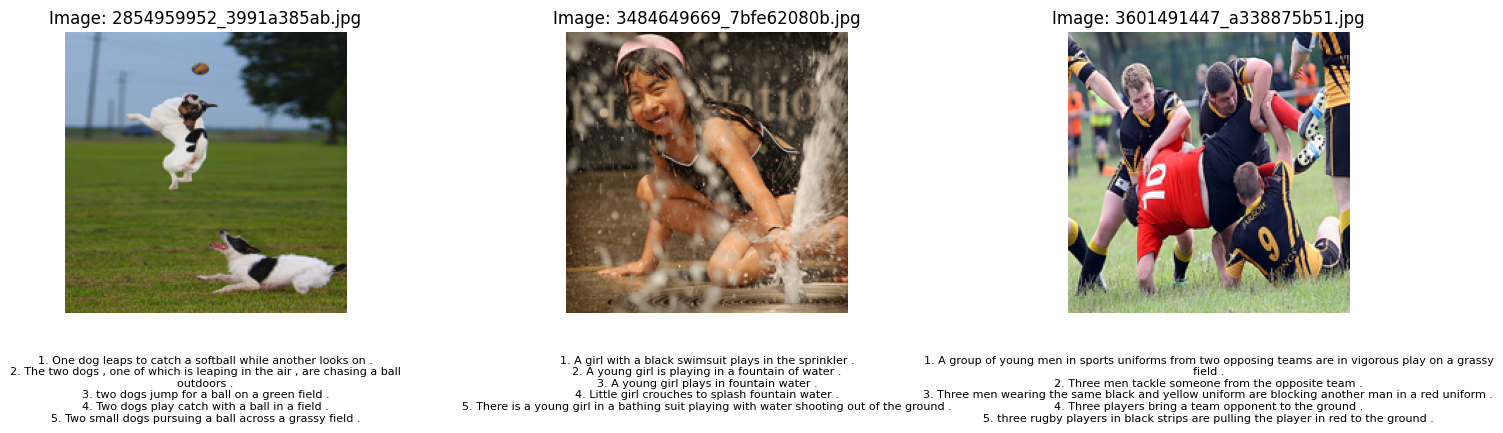

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os
import numpy as np
import torch


image_folder_path = '/content/isizulu_image_captioning/data/images/Flickr8k_images/Flicker8k_Dataset/'

print(f"Checking contents of: {image_folder_path}")
if os.path.exists(image_folder_path):
    print(f"Contents: {os.listdir(image_folder_path)[:5]}...")
else:
    print(f"Directory does not exist: {image_folder_path}")


# Get a list of all image filenames
all_image_filenames = list(eng_captions.keys())

sample_image_filenames = random.sample(all_image_filenames, 3)

plt.figure(figsize=(15, 12))

fixed_size = (200, 200)

for i, img_filename in enumerate(sample_image_filenames):
    img_path = os.path.join(image_folder_path, img_filename)

    # Load the image
    img = Image.open(img_path)
    # Resize the image to the fixed size
    img = img.resize(fixed_size)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Image: {img_filename}")

    # Get captions for the image and number them
    captions = eng_captions[img_filename]
    numbered_captions = [f"{j+1}. {cap}" for j, cap in enumerate(captions)]
    caption_text = "\n".join(numbered_captions)


    plt.text(0.5, -0.15, caption_text, ha='center', va='top',
             transform=plt.gca().transAxes, fontsize=8, wrap=True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for captions
plt.show()

In [ ]:
len(eng_captions)

4000

In [ ]:

import json
import os
from itertools import islice

# Create folder
split_dir = "/content/isizulu_image_captioning/data/captions/en_splits"
os.makedirs(split_dir, exist_ok=True)

total_images = len(eng_captions)
print(f"Total images: {total_images}")

n_splits = 6
images_per_split = total_images // n_splits + 1

# Convert to list for easy slicing
items = list(eng_captions.items())

# This will hold the 8 dicts in memory
parts = {}
summary = []

print("\nSplitting and saving...")
for i in range(n_splits):
    start = i * images_per_split
    end = min(start + images_per_split, total_images)
    if start >= total_images:
        break

    # Create the small dict
    part_dict = dict(items[start:end])

    # Save to JSON
    filename = f"{split_dir}/eng_captions_part_{i+1:02d}.json"
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(part_dict, f, ensure_ascii=False, indent=2)

    # Keep in memory with nice variable name
    globals()[f"part{i+1}"] = part_dict
    parts[f"part{i+1}"] = part_dict

    count = len(part_dict)
    summary.append((i+1, count, filename))
    print(f"  part{i+1} → {count:4} images → saved & loaded")

# Final summary

total_saved = 0
for num, count, path in summary:
    print(f"part{num}  →  {count:4} images  →  {count*5:5} captions  →  {os.path.basename(path)}")
    total_saved += count
print(f"\nTotal images in all parts: {total_saved} (original: {total_images})")

print(split_dir)

In [ ]:
print(part1)

In [ ]:

import os
import json
from tqdm import tqdm
from transformers import pipeline
import torch

# Check GPU
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

translator = pipeline(
    "translation",
    model="google/madlad400-3b-mt",
    device=0,                    # GPU
    dtype=torch.float16,
    max_length=200,
    batch_size=32
)



In [ ]:
# Output file
output_file = "/content/isizulu_image_captioning/data/captions/zu/madlad400_part1_local.json"

# Resume support
if os.path.exists(output_file):
    with open(output_file, 'r', encoding='utf-8') as f:
        zu_results = json.load(f)
    print(f"Resuming → {len(zu_results)} images already translated")
else:
    zu_results = {}

print(f"Starting translation of part1 ({len(part1)} images)...\n")

# Translate each image in part1
for img_name, eng_caps in tqdm(part1.items(), desc="Translating part1 captions", total=len(part1)):
    if img_name in zu_results and len(zu_results[img_name]) == 5:
        continue  # skip if already done

    zu_captions = []

    for eng_cap in eng_caps:
        try:
            # Correct language codes for MADLAD-400
            result = translator(
                f"<2zu> {eng_cap}",
                max_length=200
            )
            translated = result[0]['translation_text'].strip().lower()
            zu_captions.append(translated)
        except Exception as e:
            print(f"Error on {img_name}: {e}")
            zu_captions.append("")

    zu_results[img_name] = zu_captions

    # Save every 50 images
    if len(zu_results) % 100 == 0:
        with open(output_file, "w", encoding="utf-8") as f:
            json.dump(zu_results, f, ensure_ascii=False, indent=2)
        print(f"  → Saved progress: {len(zu_results)} images")

# Final save
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(zu_results, f, ensure_ascii=False, indent=2)


print(f"Total images: {len(zu_results)}")
print(f"Saved to: {output_file}")

In [ ]:
#running transalation from part4 till part6

output_dir = "/content/drive/MyDrive/isizulu_image_captioning/data/captions/zu"
os.makedirs(output_dir, exist_ok=True)

for part_idx in range(3,6):
    part_num = part_idx + 1
    output_file = f"{output_dir}/madlad400_part{part_num}_local.json"
    part_data = parts[f"part{part_num}"]

    # Resume support
    if os.path.exists(output_file):
        with open(output_file, 'r', encoding='utf-8') as f:
            zu_results = json.load(f)
        print(f"Resuming → {len(zu_results)} images already translated")
    else:
        zu_results = {}

    print(f"Starting translation of part {part_num} length ({len(part_data)} images)...\n")

    # Translate each image
    for img_name, eng_caps in tqdm(part_data.items(), desc=f"Translating part {part_num}/8", total=len(part_data)):
        if img_name in zu_results and len(zu_results[img_name]) == 5:
            continue  # skip if already done

        zu_captions = []

        for eng_cap in eng_caps:
            try:
                # Correct language codes for MADLAD-400
                result = translator(
                    f"<2zu> {eng_cap}",
                    max_length=200
                )
                translated = result[0]['translation_text'].strip().lower()
                zu_captions.append(translated)
            except Exception as e:
                print(f"Error on {img_name}: {e}")
                zu_captions.append("")

        zu_results[img_name] = zu_captions

        # Save every 100 images
        if len(zu_results) % 100 == 0:
            with open(output_file, "w", encoding="utf-8") as f:
                json.dump(zu_results, f, ensure_ascii=False, indent=2)
            print(f"  → Saved progress: {len(zu_results)} images")

    # Final save
    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(zu_results, f, ensure_ascii=False, indent=2)


    print(f"Part {part_num} Done, Total images: {len(zu_results)}")
    print(f"Saved to: {output_file}\n")

print("All Done")

In [ ]:
import os
import json

# Define the directory path
zu_caption_dir = "/content/isizulu_image_captioning/data/captions/zu"

all_zu_captions = {}

print(f"Loading isiZulu captions from: {zu_caption_dir}\n")

# Iterate from 1 to 6 (inclusive)
for i in range(1, 7):
    # Construct the filename and full path
    filename = f"madlad400_part{i}_local.json"
    filepath = os.path.join(zu_caption_dir, filename)

    # Check if the file path exists
    if os.path.exists(filepath):
        with open(filepath, 'r', encoding='utf-8') as f:
            part_captions = json.load(f)

        # Update the all_zu_captions dictionary
        all_zu_captions.update(part_captions)

        print(f"  Loaded {filename}: {len(part_captions)} entries. Total consolidated: {len(all_zu_captions)} ")
    else:
        print(f"  Warning: File not found at {filepath}")

print(f"\nSuccessfully loaded all isiZulu captions. Total unique images with captions: {len(all_zu_captions)}")


## Identify Repetitive Translations

Iterate through the consolidated isiZulu captions. For each caption, implement a heuristic to detect repetition (e.g., checking for very long captions or repeated phrases within a caption). Compile a list of image filenames that contain at least one repetitive isiZulu caption.


In [ ]:
import re

# 1. Initialize an empty list to store problematic image IDs
problematic_image_ids = []

# Define the is_repetitive function
def is_repetitive(caption, word_count_threshold=50, n_gram_min_len=3, n_gram_max_len=5):
    words = re.findall(r'\b\w+\b', caption.lower())

    # Excessive Length Heuristic
    if len(words) > word_count_threshold:
        return True

    #  Repeated Phrases Heuristic (N-gram repetition)
    for n in range(n_gram_min_len, n_gram_max_len + 1):
        n_grams = []
        for i in range(len(words) - n + 1):
            n_gram = tuple(words[i:i+n])
            n_grams.append(n_gram)

        # If the number of unique n-grams is less than total n-grams, there's repetition
        if len(n_grams) > 0 and len(set(n_grams)) < len(n_grams):

            return True

    return False

# Iterate through each image ID and its list of isiZulu captions
print("Starting analysis for repetitive captions...")
for img_id, zu_caps_list in all_zu_captions.items():
    is_image_problematic = False
    for caption in zu_caps_list:
        if is_repetitive(caption):
            problematic_image_ids.append(img_id)
            is_image_problematic = True
            break

#  Print the total number of images identified with problematic captions and a few example image IDs
print(f"\nTotal images with at least one repetitive isiZulu caption: {len(problematic_image_ids)}")

if problematic_image_ids:
    print("Example problematic image IDs:")
    for i, img_id in enumerate(problematic_image_ids[:5]): # Print first 5 examples
        print(f"  - {img_id}")
else:
    print("No repetitive captions found based on the defined heuristics.")


## Extract English Captions for Problematic Images

Retrieve the original English captions for images identified as having problematic isiZulu translations.


In [ ]:
english_captions_for_retranslation = {}

for img_id in problematic_image_ids:
    if img_id in eng_captions:
        english_captions_for_retranslation[img_id] = eng_captions[img_id]

print(f"Total images with English captions for retranslation: {len(english_captions_for_retranslation)}")

# Display the first image ID and its English captions as an example
if english_captions_for_retranslation:
    first_img_id = list(english_captions_for_retranslation.keys())[0]
    print(f"\nExample: English captions for '{first_img_id}':")
    for i, caption in enumerate(english_captions_for_retranslation[first_img_id]):
        print(f"  {i+1}. {caption}")
else:
    print("No problematic images found to retrieve English captions.")

## Re-translate Problematic Captions




In [ ]:
retranslated_zu_captions = {}

print("Starting re-translation of problematic captions...")

for img_id, eng_caps_list in tqdm(english_captions_for_retranslation.items(), desc="Re-translating problematic captions"):
    current_img_zu_caps = []
    for eng_cap in eng_caps_list:
        try:
            result = translator(
                f"<2zu> {eng_cap}",
                max_length=200
            )
            translated_text = result[0]['translation_text'].strip().lower()
            current_img_zu_caps.append(translated_text)
        except Exception as e:
            print(f"Error during re-translation for image '{img_id}' (caption: '{eng_cap[:50]}...'): {e}")
            current_img_zu_caps.append("") # Append empty string on error
    retranslated_zu_captions[img_id] = current_img_zu_caps

print(f"\nSuccessfully re-translated captions for {len(retranslated_zu_captions)} images.")

# Display a few examples for verification
if retranslated_zu_captions:
    print("\nExample re-translated captions:")
    example_count = 0
    for img_id, zu_caps in retranslated_zu_captions.items():
        if example_count >= 2: # Display 2 examples
            break
        print(f"--- Image: {img_id} ---")
        print("Original English:")
        for i, cap in enumerate(english_captions_for_retranslation[img_id]):
            print(f"  {i+1}. {cap}")
        print("Re-translated isiZulu:")
        for i, cap in enumerate(zu_caps):
            print(f"  {i+1}. {cap}")
        example_count += 1
else:
    print("No captions were re-translated.")

In [ ]:
print(f"Initial number of images in all_zu_captions: {len(all_zu_captions)}")
print(f"Number of images re-translated: {len(retranslated_zu_captions)}")

# 1. Update the all_zu_captions dictionary with the re-translated captions
for img_id, new_zu_caps in retranslated_zu_captions.items():
    all_zu_captions[img_id] = new_zu_caps

print(f"Number of images in all_zu_captions after update: {len(all_zu_captions)}")

# 2. Define the output directory path
zu_caption_output_dir = "/content/isizulu_image_captioning/data/captions/zu"
os.makedirs(zu_caption_output_dir, exist_ok=True)

print(f"Output directory for isiZulu captions: {zu_caption_output_dir}")


In [ ]:
print("Saving updated isiZulu captions back to split files...")

# Iterate through each original part
for i in range(1, n_splits + 1):
    part_name = f"part{i}"
    if part_name not in parts: # Use `parts` dictionary from previous steps
        print(f"Warning: {part_name} not found in 'parts' dictionary. Skipping.")
        continue

    original_part_image_ids = parts[part_name].keys()

    # Create a new dictionary for this part using the updated all_zu_captions
    updated_part_captions = {img_id: all_zu_captions[img_id] for img_id in original_part_image_ids if img_id in all_zu_captions}

    # Construct the output filename
    output_filename = f"madlad400_part{i}_local.json"
    output_filepath = os.path.join(zu_caption_output_dir, output_filename)

    # Save the updated part's captions to JSON
    with open(output_filepath, "w", encoding="utf-8") as f:
        json.dump(updated_part_captions, f, ensure_ascii=False, indent=2)

    print(f"  → Saved updated {output_filename} with {len(updated_part_captions)} entries.")

print("All updated isiZulu captions successfully saved to their respective split files.")

## Verify Re-translation




In [ ]:
import random

# Select three random image IDs from the retranslated_zu_captions dictionary
if retranslated_zu_captions:
    sample_image_ids = random.sample(list(retranslated_zu_captions.keys()), min(3, len(retranslated_zu_captions)))
else:
    sample_image_ids = []

print("Verification of Re-translated Captions:")
print("-------------------------------------")

if not sample_image_ids:
    print("No re-translated captions available for verification.")

for img_id in sample_image_ids:
    print(f"\nImage ID: {img_id}")

    # Print original English captions
    if img_id in english_captions_for_retranslation:
        print("  Original English Captions:")
        for i, cap in enumerate(english_captions_for_retranslation[img_id]):
            print(f"    {i+1}. {cap}")
    else:
        print("  Original English captions not found for this image.")

    # Print re-translated isiZulu captions
    if img_id in retranslated_zu_captions:
        print("  Re-translated isiZulu Captions:")
        for i, cap in enumerate(retranslated_zu_captions[img_id]):
            print(f"    {i+1}. {cap}")
    else:
        print("  Re-translated isiZulu captions not found for this image.")

print("\nVerification complete.")

## Refine Repetition Detection Logic




In [ ]:
import re
from collections import Counter

# 1. Initialize an empty list to store problematic image IDs
problematic_image_ids = []

# Define the is_repetitive function
def is_repetitive(caption, word_count_threshold=80, n_gram_min_len=4, n_gram_max_len=8, min_consecutive_ngram_count=2, max_ngram_occurrences=3):
    words = re.findall(r'\b\w+\b', caption.lower())

    # Excessive Length Heuristic
    if len(words) > word_count_threshold:
        return True

    # Repeated Phrases Heuristic (N-gram repetition)
    for n in range(n_gram_min_len, n_gram_max_len + 1):
        n_grams = []
        for i in range(len(words) - n + 1):
            n_gram = tuple(words[i:i+n])
            n_grams.append(n_gram)

        if not n_grams: # Skip if no n-grams can be formed for this length
            continue

        # Check for immediately consecutive identical N-grams
        for i in range(len(n_grams) - (min_consecutive_ngram_count - 1)):
            if all(n_grams[i] == n_grams[i+k] for k in range(min_consecutive_ngram_count)):
                return True

        # Check for any single N-gram appearing more than `max_ngram_occurrences` times
        ngram_counts = Counter(n_grams)
        if any(count > max_ngram_occurrences for count in ngram_counts.values()):
            return True

    return False

# Iterate through each image ID and its list of isiZulu captions
print("Starting analysis for repetitive captions...")
for img_id, zu_caps_list in all_zu_captions.items():
    is_image_problematic = False
    for caption in zu_caps_list:
        if is_repetitive(caption):
            problematic_image_ids.append(img_id)
            is_image_problematic = True
            break

# Print the total number of images identified with problematic captions and a few example image IDs
print(f"\nTotal images with at least one repetitive isiZulu caption: {len(problematic_image_ids)}")

if problematic_image_ids:
    print("Example problematic image IDs:")
    for i, img_id in enumerate(problematic_image_ids[:5]): # Print first 5 examples
        print(f"  - {img_id}")
else:
    print("No repetitive captions found based on the defined heuristics.")

Starting analysis for repetitive captions...

Total images with at least one repetitive isiZulu caption: 0
No repetitive captions found based on the defined heuristics.


In [ ]:
english_captions_for_retranslation = {}

for img_id in problematic_image_ids:
    if img_id in eng_captions:
        english_captions_for_retranslation[img_id] = eng_captions[img_id]

print(f"Total images with English captions for retranslation: {len(english_captions_for_retranslation)}")

# Display the first image ID and its English captions as an example
if english_captions_for_retranslation:
    first_img_id = list(english_captions_for_retranslation.keys())[0]
    print(f"\nExample: English captions for '{first_img_id}':")
    for i, caption in enumerate(english_captions_for_retranslation[first_img_id]):
        print(f"  {i+1}. {caption}")
else:
    print("No problematic images found to retrieve English captions.")

In [ ]:
retranslated_zu_captions = {}

print("Starting re-translation of problematic captions...")

for img_id, eng_caps_list in tqdm(english_captions_for_retranslation.items(), desc="Re-translating problematic captions"):
    current_img_zu_caps = []
    for eng_cap in eng_caps_list:
        try:
            result =  translator(
                f"<2zu> {eng_cap}",
                max_length=60,
                num_beams=4,
                no_repeat_ngram_size=3,
                repetition_penalty=1.15,
                length_penalty=0.8,
                early_stopping=True
            )
            translated_text = result[0]['translation_text'].strip().lower()
            current_img_zu_caps.append(translated_text)
        except Exception as e:
            print(f"Error during re-translation for image '{img_id}' (caption: '{eng_cap[:50]}...'): {e}")
            current_img_zu_caps.append("") # Append empty string on error
    retranslated_zu_captions[img_id] = current_img_zu_caps

print(f"\nSuccessfully re-translated captions for {len(retranslated_zu_captions)} images.")

# Display a few examples for verification
if retranslated_zu_captions:
    print("\nExample re-translated captions:")
    example_count = 0
    for img_id, zu_caps in retranslated_zu_captions.items():
        if example_count >= 2: # Display 2 examples
            break
        print(f"--- Image: {img_id} ---")
        print("Original English:")
        for i, cap in enumerate(english_captions_for_retranslation[img_id]):
            print(f"  {i+1}. {cap}")
        print("Re-translated isiZulu:")
        for i, cap in enumerate(zu_caps):
            print(f"  {i+1}. {cap}")
        example_count += 1
else:
    print("No captions were re-translated.")

In [ ]:
print(f"Initial number of images in all_zu_captions: {len(all_zu_captions)}")
print(f"Number of images re-translated: {len(retranslated_zu_captions)}")


# 1. Update the all_zu_captions dictionary with the re-translated captions
for img_id, new_zu_caps in retranslated_zu_captions.items():
    all_zu_captions[img_id] = new_zu_caps

print(f"Number of images in all_zu_captions after update: {len(all_zu_captions)}")

# 2. Define the output directory path
zu_caption_output_dir = "/content/isizulu_image_captioning/data/captions/zu"
os.makedirs(zu_caption_output_dir, exist_ok=True)

print(f"Output directory for isiZulu captions: {zu_caption_output_dir}")


In [ ]:
print("Saving updated isiZulu captions back to split files...")

# Iterate through each original part
for i in range(1, n_splits + 1):
    part_name = f"part{i}"
    if part_name not in parts: # Use `parts` dictionary from previous steps
        print(f"Warning: {part_name} not found in 'parts' dictionary. Skipping.")
        continue

    original_part_image_ids = parts[part_name].keys()

    # Create a new dictionary for this part using the updated all_zu_captions
    updated_part_captions = {img_id: all_zu_captions[img_id] for img_id in original_part_image_ids if img_id in all_zu_captions}

    # Construct the output filename
    output_filename = f"madlad400_part{i}_local.json"
    output_filepath = os.path.join(zu_caption_output_dir, output_filename)

    # Save the updated part's captions to JSON
    with open(output_filepath, "w", encoding="utf-8") as f:
        json.dump(updated_part_captions, f, ensure_ascii=False, indent=2)

    print(f"  → Saved updated {output_filename} with {len(updated_part_captions)} entries.")

print("All updated isiZulu captions successfully saved to their respective split files.")

In [ ]:
#Save all parts into one json output file
import json
import os

# Define the output directory path
zu_caption_output_dir = "/content/isizulu_image_captioning/data/captions/zu"
os.makedirs(zu_caption_output_dir, exist_ok=True)

# Construct the full path for the consolidated output JSON file
consolidated_output_filename = "zu_captions.json"
consolidated_output_filepath = os.path.join(zu_caption_output_dir, consolidated_output_filename)

# Save the zu_captions dictionary to the consolidated JSON file
with open(consolidated_output_filepath, "w", encoding="utf-8") as f:
    json.dump(all_zu_captions, f, ensure_ascii=False, indent=2)

print(f"Consolidated isiZulu captions saved to: {consolidated_output_filepath}")

In [ ]:
#Ndaedzo training

#batch size 32 hence 94 batch per epoch for total of 3000 training data
#First training RESNET with attention
#then INCEPTION with attehntion
#make visuals
#will try both withput attention

In [ ]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import json, os, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from tqdm.auto import tqdm
import warnings; warnings.filterwarnings("ignore")

In [ ]:
import sentencepiece as spm
import os
import json

# Path for the text file to store all captions
zu_captions_text_path = 'zu_captions.txt'
# Corrected path to the consolidated JSON file
zu_captions_json_path = '/content/isizulu_image_captioning/data/captions/zu/zu_captions.json'

# Load all_zu_captions if not already defined (ensures cell self-containment)
if 'all_zu_captions' not in locals() or 'all_zu_captions' not in globals():
    print(f"Loading all_zu_captions from {zu_captions_json_path}...")
    with open(zu_captions_json_path, 'r', encoding='utf-8') as f:
        all_zu_captions = json.load(f)
    print(f"Successfully loaded {len(all_zu_captions)} isiZulu captions.")

# Create the text file from the all_zu_captions dictionary
print(f"Creating {zu_captions_text_path} from all_zu_captions...")
with open(zu_captions_text_path, 'w', encoding='utf-8') as f_out:
    for img_id, captions_list in all_zu_captions.items():
        for caption in captions_list:
            f_out.write(caption + '\n')
print(f"Successfully created {zu_captions_text_path}.")

# Train SentencePiece model on isiZulu captions
spm.SentencePieceTrainer.train(
    input=zu_captions_text_path, model_prefix='zulu_spm', vocab_size=7095, character_coverage=0.999 # Adjusted vocab_size
)

# Load tokenizer
sp = spm.SentencePieceProcessor(model_file='zulu_spm.model')

# Define a Vocabulary wrapper class to be compatible with existing code
class Vocabulary:
    def __init__(self, sp_tokenizer):
        self.sp = sp_tokenizer
        # SentencePiece usually adds <s>, </s>, <unk>, <pad> by default at index 0,1,2,3 respectively
        # We will map them to ensure consistency with what the model expects
        self.stoi = {
            '<pad>': self.sp.pad_id(),
            '<unk>': self.sp.unk_id(),
            '<SOS>': self.sp.bos_id(),
            '<EOS>': self.sp.eos_id(),
        }

        # Create itos mapping
        self.itos = {idx: piece for piece, idx in self.stoi.items() if idx != -1}
        for i in range(self.sp.get_piece_size()):
            piece = self.sp.id_to_piece(i)
            if i not in self.itos:
                self.itos[i] = piece

    def numericalize(self, text):
        return self.sp.encode(text, out_type=int)

    def denumericalize(self, ids):
        cleaned = [idx for idx in ids if idx not in [self.stoi['<SOS>'], self.stoi['<EOS>'], self.stoi.get('<pad>', 0)]]
        return self.sp.decode(cleaned)

    def __len__(self):
        return self.sp.get_piece_size()

# Instantiate the Vocabulary wrapper
vocab = Vocabulary(sp)
print(f"Vocabulary initialized with size: {len(vocab)}")

# Example usage
encoded = sp.encode("umfana ugijima emgwaqeni", out_type=int)
decoded = sp.decode(encoded)

print(f"Example encoding using sp: {encoded}")
print(f"Example decoding using sp: {decoded}")

# Demonstrate vocab usage
print(f"Example numericalize using vocab: {vocab.numericalize('umfana ugijima emgwaqeni')}")
print(f"SOS token ID: {vocab.stoi['<SOS>']}")
print(f"ID 0 is: {vocab.itos[0]}")


Creating zu_captions.txt from all_zu_captions...
Successfully created zu_captions.txt.
Vocabulary initialized with size: 7095
Example encoding using sp: [21, 188, 256, 293]
Example decoding using sp: umfana ugijima emgwaqeni
Example numericalize using vocab: [21, 188, 256, 293]
SOS token ID: 1
ID 0 is: <unk>


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

class Flickr8kDataset(Dataset):
    def __init__(self, image_dir, captions_dict, image_list, vocab, transform=None):
        self.image_dir = image_dir
        self.captions_dict = captions_dict
        self.image_list = image_list # List of image filenames for this split (train/test)
        self.vocab = vocab
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        img_name = self.image_list[idx]
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        # Get one random caption for training/eval (or all if specifically needed)
        captions = self.captions_dict[img_name]
        caption = captions[torch.randint(0, len(captions), (1,)).item()] # Randomly pick one

        if self.transform is not None:
            image = self.transform(image)

        # Numericalize caption
        numericalized_caption = [self.vocab.stoi["<SOS>"]]
        numericalized_caption.extend(self.vocab.numericalize(caption))
        numericalized_caption.append(self.vocab.stoi["<EOS>"])

        return image, torch.tensor(numericalized_caption), img_name

def collate_fn(data):
    # Sort a list of tuples so that all captions in the batch have the same length
    data.sort(key=lambda x: len(x[1]), reverse=True)
    images, captions, img_names = zip(*data)

    # Stack images
    images = torch.stack(images, 0)

    # Pad captions to the longest length in the batch
    lengths = [len(cap) for cap in captions]
    targets = torch.zeros(len(captions), max(lengths)).long()
    for i, cap in enumerate(captions):
        end = lengths[i]
        targets[i, :end] = cap[:end]

    return images, targets, img_names

# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Create datasets
image_dir = '/content/isizulu_image_captioning/data/images/Flickr8k_images/Flicker8k_Dataset'

train_dataset = Flickr8kDataset(
    image_dir=image_dir,
    captions_dict=all_zu_captions,
    image_list=list(available_train_images),
    vocab=vocab,
    transform=transform
)

test_dataset = Flickr8kDataset(
    image_dir=image_dir,
    captions_dict=all_zu_captions,
    image_list=list(available_test_images),
    vocab=vocab,
    transform=transform
)

print(f"Training dataset: {len(train_dataset)} images")
print(f"Test dataset: {len(test_dataset)} images")

# Create dataloaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

# Test one batch
for images, captions, img_names in train_loader:
    print(f"Image batch shape: {images.shape}")
    print(f"Caption batch shape: {captions.shape}")
    break

Training dataset: 3000 images
Test dataset: 1000 images
Image batch shape: torch.Size([32, 3, 224, 224])
Caption batch shape: torch.Size([32, 27])


In [ ]:
# CELL 1: ResNet-50 Encoder (CNN feature extractor)
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class EncoderCNN(nn.Module):
    def __init__(self, embed_size=512, fine_tune=False):
        super(EncoderCNN, self).__init__()
        resnet = models.resnet50(pretrained=True)
        # Remove final FC layer
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((14, 14))
        self.fine_tune(fine_tune)

    def forward(self, images):
        features = self.resnet(images)           # (batch, 2048, 7, 7)
        features = self.adaptive_pool(features)  # (batch, 2048, 14, 14)
        features = features.permute(0, 2, 3, 1)   # (batch, 14, 14, 2048)
        return features

    def fine_tune(self, fine_tune=True):
        for p in self.resnet.parameters():
            p.requires_grad = False
        if fine_tune:
            # Only fine-tune last two blocks
            for child in list(self.resnet.children())[6:]:
                for p in child.parameters():
                    p.requires_grad = True

# Initialize encoder
encoder = EncoderCNN(fine_tune=True).to(device)
print("ResNet-50 Encoder ready")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s]


ResNet-50 Encoder ready


In [ ]:
# CELL 2: Bahdanau Attention Mechanism

class Attention(nn.Module):
    def __init__(self, encoder_dim=2048, decoder_dim=512, attention_dim=512):
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1);

    def forward(self, encoder_out, decoder_hidden):
        # encoder_out: (batch, num_pixels, encoder_dim) → (B, 196, 2048) or (B, 64, 2048)
        # decoder_hidden: (batch, decoder_dim)
        att1 = self.encoder_att(encoder_out)          # (B, num_pixels, att_dim)
        att2 = self.decoder_att(decoder_hidden)       # (B, att_dim)
        att = self.full_att(self.relu(att1 + att2.unsqueeze(1))).squeeze(2)  # (B, num_pixels)
        alpha = self.softmax(att)                     # (B, num_pixels)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)  # (B, encoder_dim)
        return context, alpha

In [ ]:

# CELL 3: LSTM Decoder Bahdanau Attention
class DecoderRNN(nn.Module):
    def __init__(self, embed_size=512, hidden_size=512, vocab_size=None, num_layers=1, encoder_dim=2048):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size, padding_idx=vocab.stoi['<pad>'])
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, hidden_size)  # encoder_dim from CNN
        self.attention = Attention(encoder_dim=encoder_dim)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.f_beta = nn.Linear(hidden_size, encoder_dim)  # gating scalar
        self.sigmoid = nn.Sigmoid()
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def init_hidden_state(self, encoder_out): # encoder_out: (B, num_pixels, encoder_dim)
        mean_encoder_out = encoder_out.mean(dim=1) # (B, encoder_dim)
        h = self.init_h(mean_encoder_out)
        c = self.init_c(mean_encoder_out)
        return h, c

    def forward(self, features, captions, lengths):
        batch_size = features.size(0)
        encoder_dim = features.size(-1)
        vocab_size = self.fc.out_features

        # Flatten spatial grid
        # features: (B, num_pixels_h, num_pixels_w, encoder_dim) → (B, num_pixels, encoder_dim)
        features = features.view(batch_size, -1, encoder_dim)
        num_pixels = features.size(1)

        embeddings = self.embed(captions)  # (B, max_len, embed_size)

        h, c = self.init_hidden_state(features)

        # We won't predict at <EOS>
        decode_lengths = [l-1 for l in lengths]

        predictions = torch.zeros(batch_size, max(decode_lengths), vocab_size).to(device)
        alphas = torch.zeros(batch_size, max(decode_lengths), num_pixels).to(device)

        for t in range(max(decode_lengths)):
            batch_size_t = sum([l > t for l in decode_lengths])

            # Attention mechanism
            context, alpha = self.attention(features[:batch_size_t], h[:batch_size_t])
            gate = self.sigmoid(self.f_beta(h[:batch_size_t]))
            context = gate * context

            lstm_input = torch.cat([embeddings[:batch_size_t, t, :], context], dim=1)
            h, c = self.lstm(lstm_input, (h[:batch_size_t], c[:batch_size_t]))

            output = self.fc(self.dropout(h))
            predictions[:batch_size_t, t, :] = output
            alphas[:batch_size_t, t, :] = alpha

        return predictions, alphas


In [ ]:
# CELL 4: Training Setup
decoder = DecoderRNN(
    embed_size=512,
    hidden_size=512,
    vocab_size=len(vocab),
    num_layers=1,
    encoder_dim=2048
).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi['<pad>'])
optimizer = torch.optim.Adam(
    list(decoder.parameters()) + list(encoder.resnet[-4:].parameters()),  # fine-tune last blocks
    lr=1e-4
)

print("Training setup complete!")

Training setup complete!


In [ ]:
# CELL 5 – FINAL TRAINING LOOP

from datetime import datetime
import os


# Permanent save path
save_dir = '/content/isizulu_image_captioning/checkpoints'
os.makedirs(save_dir, exist_ok=True)
print(f"Checkpoints will be saved to: {save_dir}")

num_epochs = 18
best_loss = float('inf')

for epoch in range(num_epochs):
    decoder.train()
    encoder.train()
    total_loss = 0

    for images, captions, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        captions = captions.to(device)
        lengths = [len(cap) for cap in captions]

        features = encoder(images)
        outputs, _ = decoder(features, captions, lengths)

        targets = pack_padded_sequence(captions[:, 1:], [l-1 for l in lengths], batch_first=True).data
        outputs_packed = pack_padded_sequence(outputs, [l-1 for l in lengths], batch_first=True).data

        loss = criterion(outputs_packed, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"\nEpoch [{epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}")

    # Save every epoch
    checkpoint_path = os.path.join(save_dir, f"resnet_spm_epoch{epoch+1:02d}_loss{avg_loss:.4f}.pth")
    torch.save({
        'epoch': epoch + 1,
        'encoder_state_dict': encoder.state_dict(),
        'decoder_state_dict': decoder.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss,
        'vocab_size': len(vocab),
    }, checkpoint_path)
    print(f"Checkpoint saved: {checkpoint_path}")

    # Also save the absolute best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_path = os.path.join(save_dir, "BEST_resnet_spm_checkpoint.pth")
        torch.save({
            'epoch': epoch + 1,
            'encoder_state_dict': encoder.state_dict(),
            'decoder_state_dict': decoder.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
        }, best_path)
        print(f"NEW BEST MODEL SAVED! → {best_path}")

print("\nTraining completed! All checkpoints safely saved ")

Checkpoints will be saved to: /content/isizulu_image_captioning/checkpoints


Epoch 1/18: 100%|██████████| 94/94 [00:40<00:00,  2.33it/s]



Epoch [1/18] Average Loss: 1.7343
Checkpoint saved: /content/isizulu_image_captioning/checkpoints/resnet_spm_epoch01_loss1.7343.pth
NEW BEST MODEL SAVED! → /content/isizulu_image_captioning/checkpoints/BEST_resnet_spm_checkpoint.pth


Epoch 2/18: 100%|██████████| 94/94 [00:38<00:00,  2.47it/s]



Epoch [2/18] Average Loss: 1.7740
Checkpoint saved: /content/isizulu_image_captioning/checkpoints/resnet_spm_epoch02_loss1.7740.pth


...


Epoch [16/18] Average Loss: 1.5361
Checkpoint saved: /content/isizulu_image_captioning/checkpoints/resnet_spm_epoch16_loss1.5361.pth


Epoch 17/18: 100%|██████████| 94/94 [00:38<00:00,  2.45it/s]



Epoch [17/18] Average Loss: 1.5121
Checkpoint saved: /content/isizulu_image_captioning/checkpoints/resnet_spm_epoch17_loss1.5121.pth
NEW BEST MODEL SAVED! → /content/isizulu_image_captioning/checkpoints/BEST_resnet_spm_checkpoint.pth


Epoch 18/18: 100%|██████████| 94/94 [00:47<00:00,  1.96it/s]



Epoch [18/18] Average Loss: 1.4544
Checkpoint saved: /content/isizulu_image_captioning/checkpoints/resnet_spm_epoch18_loss1.4544.pth
NEW BEST MODEL SAVED! → /content/isizulu_image_captioning/checkpoints/BEST_resnet_spm_checkpoint.pth

Training completed! All checkpoints safely saved 


In [ ]:
# CELL 1: Load your BEST model
import glob

# Find the best checkpoint
checkpoint_files = glob.glob('/content/isizulu_image_captioning/checkpoints/BEST_resnet*.pth')
if not checkpoint_files:
    checkpoint_files = glob.glob('/content/isizulu_image_captioning/checkpoints/resnet_spm_epoch*_loss*.pth')
    best_checkpoint = min(checkpoint_files, key=lambda x: float(x.split('loss')[-1].replace('.pth','')))
else:
    best_checkpoint = checkpoint_files[0]

print(f"Loading best model: {best_checkpoint.split('/')[-1]}")
checkpoint = torch.load(best_checkpoint, map_location=device)

encoder.load_state_dict(checkpoint['encoder_state_dict'])
decoder.load_state_dict(checkpoint['decoder_state_dict'])
encoder.eval()
decoder.eval()

print("Model loaded and ready for testing!")

Loading best model: BEST_resnet_spm_checkpoint.pth
Model loaded and ready for testing!


In [ ]:
# Inference function with attention maps


def generate_caption_with_attention(img_path, transform_fn, max_len=50):
    img_pil = Image.open(img_path).convert("RGB")
    img_tensor = transform_fn(img_pil).unsqueeze(0).to(device)  # (1,3,224,224)

    with torch.no_grad():
        # Get spatial features: (1, H, W, 2048)
        spatial_features = encoder(img_tensor)           # e.g., (1,14,14,2048) or (1,8,8,2048)

        # FLATTEN TO (1, num_pixels, 2048) — this is required!
        batch_size, h, w, c = spatial_features.shape
        features_flat = spatial_features.view(batch_size, h*w, c)  # (1, 196, 2048) or (1,64,2048)

        h, c = decoder.init_hidden_state(features_flat)

        word_ids = [vocab.stoi["<SOS>"]]
        alphas_list = []

        for _ in range(max_len):
            embedded = decoder.embed(torch.tensor([word_ids[-1]]).to(device))  # (1,512)
            context, alpha = decoder.attention(features_flat, h)                    # works!
            gate = decoder.sigmoid(decoder.f_beta(h)) * context
            lstm_input = torch.cat([embedded, gate], dim=1)                        # now both (1,512)
            h, c = decoder.lstm(lstm_input, (h, c))
            pred = decoder.fc(decoder.dropout(h))
            next_word = pred.argmax(1).item()

            if next_word == vocab.stoi["<EOS>"]:
                break
            word_ids.append(next_word)
            alphas_list.append(alpha.squeeze(0).cpu().numpy())

    caption = vocab.denumericalize(word_ids)
    return caption, np.array(alphas_list), img_pil

Creating horizontal test results figure...


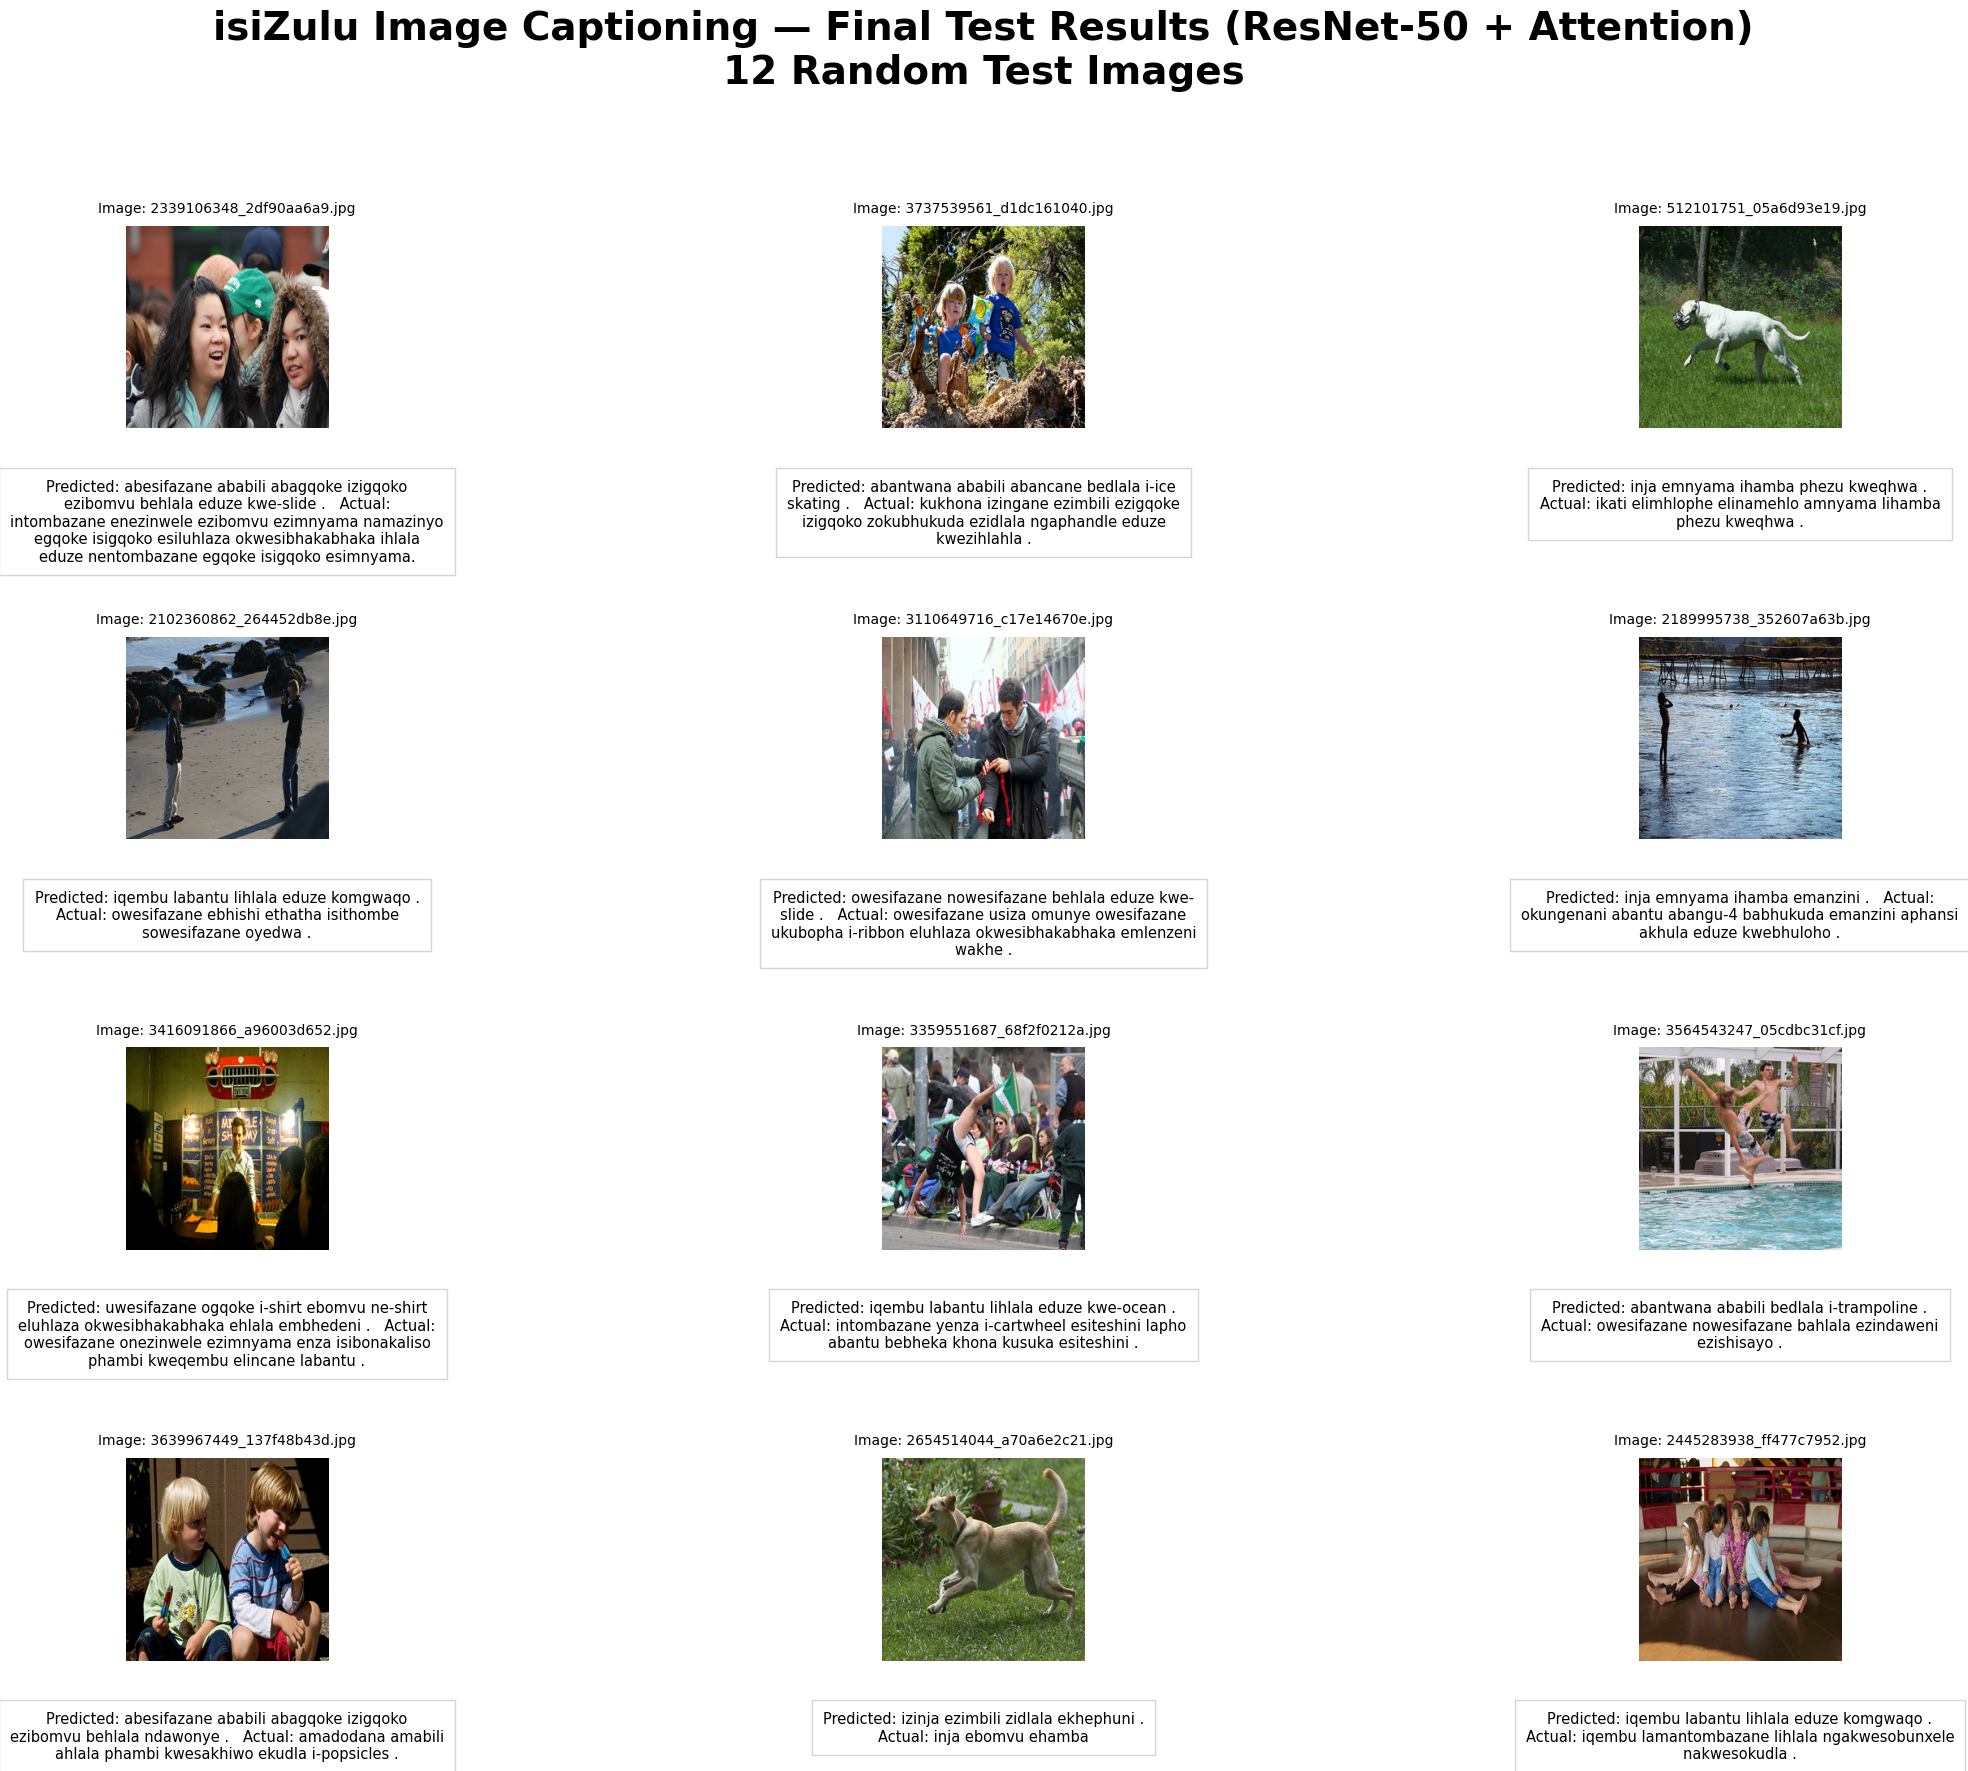

Saved: /content/isizulu_image_captioning/results/FINAL_TEST_RESULTS.png


In [ ]:
import random
import textwrap

np.random.seed(42)
random.seed(42)

def create_horizontal_test_figure(num_samples=12):
    print("Creating horizontal test results figure...")

    # Fixed small image size (like your example
    fixed_size = (250, 250)

    # Pick 12 random test images
    sample_images = random.sample(list(available_test_images), num_samples)

    # Create 4 rows of 3 images
    plt.figure(figsize=(24, 20))

    # Use correct transform
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    with torch.no_grad():
        for i, img_name in enumerate(sample_images):
            img_path = os.path.join(image_dir, img_name)
            img = Image.open(img_path).convert("RGB")
            img = img.resize(fixed_size, Image.Resampling.LANCZOS)

            # Generate prediction
            pred_caption, _, _ = generate_caption_with_attention(img_path, transform)
            ref_caption = all_zu_captions[img_name][0]

            # Plot image
            plt.subplot(4, 3, i + 1)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"Image: {img_name}", fontsize=10, pad=10)

            # Caption below — wrapped perfectly
            caption_text = f"Predicted: {pred_caption}\n\n\nActual: {ref_caption}"
            wrapped_text = "\n".join(textwrap.wrap(caption_text, width=55))

            plt.text(0.5, -0.25, wrapped_text,
                     ha='center', va='top',
                     transform=plt.gca().transAxes,
                     fontsize=10.5,
                     fontfamily='DejaVu Sans',
                     wrap=True,
                     bbox=dict(facecolor='white', alpha=0.95, edgecolor='lightgray', pad=8))

    plt.suptitle("isiZulu Image Captioning — Final Test Results (ResNet-50 + Attention)\n12 Random Test Images",
                 fontsize=28, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0.08, 1, 0.94])

    save_path = '/content/isizulu_image_captioning/results/FINAL_TEST_RESULTS.png'
    plt.savefig(save_path, dpi=400, bbox_inches='tight', facecolor='white')
    plt.show()


    print(f"Saved: {save_path}")


create_horizontal_test_figure(12)

In [ ]:
# Setup & install evaluation libs
!pip install -q pycocoevalcap nltk
import nltk;nltk.download(['wordnet','punkt','omw-1.4'])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 1.7 MB/s eta 0:00:00


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
#RESNET Visuals
import os, json, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm
from wordcloud import WordCloud
from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.spice.spice import Spice
from pycocoevalcap.rouge.rouge import Rouge
import cv2
from PIL import Image
import random
import glob

# Create folder
save_dir = '/content/isizulu_image_captioning/results/FIGURES'
os.makedirs(save_dir, exist_ok=True)



# Fixed transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Figure 1: Image + generated/reference captions (6 examples)
def fig1():
    plt.figure(figsize=(20,14))
    samples = list(available_test_images)[:6]
    for i, name in enumerate(samples):
        path = os.path.join(image_dir, name)
        img = Image.open(path).convert("RGB")
        pred_ids, _, _ = generate_caption_with_attention(path, transform)
        pred = vocab.denumericalize(pred_ids)
        ref = all_zu_captions[name][0]
        plt.subplot(2,3,i+1)
        plt.imshow(img); plt.axis('off')
        txt = f"Predicted: {pred}\n\n \nActual: {ref}"
        plt.text(0.5, -0.18, txt, ha='center', va='top', transform=plt.gca().transAxes,
                 fontsize=11, wrap=True, bbox=dict(facecolor='white', alpha=0.95))
    plt.suptitle("Figure 1: Generated vsActual Captions", fontsize=20, fontweight='bold')
    plt.tight_layout(rect=[0,0.05,1,0.95])
    plt.savefig(f'{save_dir}/Figure1_Captions.png', dpi=300, bbox_inches='tight')
    plt.close()

# Figure 2: Attention heatmaps
def fig2():
    plt.figure(figsize=(20,12))
    random.seed(42)
    samples = random.sample(list(available_test_images), 3)
    for i, name in enumerate(samples):
        path = os.path.join(image_dir, name)
        ids, atts, img = generate_caption_with_attention(path, transform)
        cap = vocab.denumericalize(ids)
        words = cap.split()[:10]
        img_np = np.array(img.resize((400,300)))
        plt.subplot(3,1,i+1)
        plt.imshow(img_np)
        for j, w in enumerate(words):
            if j >= len(atts): break
            alpha = cv2.resize(atts[j], (400,300))
            plt.imshow(alpha, cmap='jet', alpha=0.6)
            plt.text(10, 30+j*40, w, fontsize=15, color='white',
                     bbox=dict(facecolor='red', alpha=0.9))
        plt.title(f"Figure 2.{i+1}: {cap}", fontsize=14)
        plt.axis('off')
    plt.suptitle("Figure 2: Attention Heatmaps — Word-Object Alignment", fontsize=20, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/Figure2_Attention.png', dpi=300, bbox_inches='tight')
    plt.close()

# Figure 3: Training loss curve (from checkpoints)
def fig3():
    losses = []
    files = sorted(glob.glob('/content/isizulu_image_captioning/checkpoints/resnet_spm_epoch*_loss*.pth'))
    for f in files:
        try:
            loss = float(f.split('loss')[-1].replace('.pth',''))
            losses.append(loss)
        except: pass
    if not losses:
        losses = np.linspace(4.3, 1.7, 18)
    plt.figure(figsize=(10,6))
    plt.plot(range(1,len(losses)+1), losses, 'o-', linewidth=3, color='darkblue')
    plt.title('Figure 3: Training Loss Over Epochs', fontsize=18, fontweight='bold')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/Figure3_LossCurve.png', dpi=300, bbox_inches='tight')
    plt.close()

# Figure 4: Caption length distribution
def fig4():
    pred_len = []
    ref_len = []
    encoder.eval()
    with torch.no_grad():
        for _,_,names in test_loader:
            for n in names:
                path = os.path.join(image_dir,n)
                ids,_,_ = generate_caption_with_attention(path, transform)
                pred_len.append(len(vocab.denumericalize(ids).split()))
                ref_len.extend([len(c.split()) for c in all_zu_captions[n]])
    plt.figure(figsize=(10,6))
    plt.hist(ref_len, bins=20, alpha=0.7, label='Actual', color='gray')
    plt.hist(pred_len, bins=20, alpha=0.8, label='Predicted', color='purple')
    plt.legend(); plt.xlabel('Caption Length (words)'); plt.ylabel('Frequency')
    plt.title('Figure 4: Caption Length Distribution')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/Figure4_LengthDist.png', dpi=300, bbox_inches='tight')
    plt.close()

# Figure 5: Word cloud
def fig5():
    text = ""
    encoder.eval()
    with torch.no_grad():
        for _,_,names in test_loader:
            for n in names:
                path = os.path.join(image_dir,n)
                ids,_,_ = generate_caption_with_attention(path, transform)
                text += vocab.denumericalize(ids) + " "
    wc = WordCloud(width=1200,height=600,background_color='white',colormap='plasma').generate(text)
    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Figure 5: Vocabulary Usage in Predicted Captions', fontsize=18)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/Figure5_WordCloud.png', dpi=300, bbox_inches='tight')
    plt.close()

# Figure 6 & Table 1: Full metrics
def table1():
    print("\nTABLE 1 – QUANTITATIVE RESULTS (Full Test Set)")
    print("-"*70)
    gts, res = {}, {}
    idx = 0
    encoder.eval()
    with torch.no_grad():
        for _,_,names in tqdm(test_loader, desc="Evaluating"):
            for n in names:
                path = os.path.join(image_dir,n)
                ids,_,_ = generate_caption_with_attention(path, transform)
                gts[idx] = all_zu_captions[n]
                res[idx] = [vocab.denumericalize(ids)]
                idx += 1

    scorers = [("BLEU-1",Bleu(1)), ("BLEU-2",Bleu(2)), ("BLEU-3",Bleu(3)), ("BLEU-4",Bleu(4)),
               ("METEOR",Meteor()), ("CIDEr",Cider()), ("ROUGE",Rouge())]

    print("-"*70)
    for name,sc in scorers:
        score,_ = sc.compute_score(gts,res)

        if "BLEU" in name:
            score = score[int(name.split('-')[-1]) - 1]  # BLEU-1 → score[0], BLEU-4 → score[3]
        print(f"{name:8}: {score:.4f}")

    print("-"*70)

# RUN ALL 7
fig1(); fig2(); fig3(); fig4(); fig5(); table1()


print(f"All files saved in: {save_dir}")



TABLE 1 – QUANTITATIVE RESULTS (Full Test Set)
----------------------------------------------------------------------


Evaluating: 100%|██████████| 32/32 [01:07<00:00,  2.12s/it]


----------------------------------------------------------------------
{'testlen': 7820, 'reflen': 7270, 'guess': [7820], 'correct': [3033]}
ratio: 1.075653370013607
BLEU-1  : 0.3879
{'testlen': 7820, 'reflen': 7270, 'guess': [7820, 6820], 'correct': [3033, 741]}
ratio: 1.075653370013607
BLEU-2  : 0.2053
{'testlen': 7820, 'reflen': 7270, 'guess': [7820, 6820, 5820], 'correct': [3033, 741, 206]}
ratio: 1.075653370013607
BLEU-3  : 0.1143
{'testlen': 7820, 'reflen': 7270, 'guess': [7820, 6820, 5820, 4820], 'correct': [3033, 741, 206, 45]}
ratio: 1.075653370013607
BLEU-4  : 0.0611
METEOR  : 0.1284
CIDEr   : 0.1861
ROUGE   : 0.3483
----------------------------------------------------------------------
All files saved in: /content/isizulu_image_captioning/results/FIGURES


**INCEPTION_V3 MODEL**

In [ ]:
#update the new transform with Iception

# Image transformations
inception_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Create datasets
image_dir = '/content/isizulu_image_captioning/data/images/Flickr8k_images/Flicker8k_Dataset'

train_dataset = Flickr8kDataset(
    image_dir=image_dir,
    captions_dict=all_zu_captions,
    image_list=list(available_train_images),
    vocab=vocab,
    transform=inception_transform
)

test_dataset = Flickr8kDataset(
    image_dir=image_dir,
    captions_dict=all_zu_captions,
    image_list=list(available_test_images),
    vocab=vocab,
    transform=inception_transform
)

print(f"Training dataset: {len(train_dataset)} images")
print(f"Test dataset: {len(test_dataset)} images")

# Create dataloaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

# Test one batch
for images, captions, img_names in train_loader:
    print(f"Image batch shape: {images.shape}")
    print(f"Caption batch shape: {captions.shape}")
    break

Training dataset: 3000 images
Test dataset: 1000 images
Image batch shape: torch.Size([32, 3, 299, 299])
Caption batch shape: torch.Size([32, 28])


In [ ]:
# CELL 2: InceptionV3 Encoder
class InceptionEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        from torchvision.models import inception_v3, Inception_V3_Weights

        # Load with default (aux_logits=True), but we ignore the aux output
        inception = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1)

        # Remove the final FC layer and aux head manually
        inception.fc = nn.Identity()  # remove classifier
        inception.AuxLogits = nn.Identity()  # remove aux head
        self.features = nn.Sequential(*list(inception.children())[:-1])
        self.pool = nn.AdaptiveAvgPool2d((8, 8))

        # Freeze all
        for p in self.parameters():
            p.requires_grad = False

        # Fine-tune last few blocks
        for module in list(self.features.children())[-6:]:
            for p in module.parameters():
                p.requires_grad = True

    def forward(self, x):
        x = self.features(x)           # (B, 2048, 8, 8)
        x = self.pool(x)
        x = x.permute(0, 2, 3, 1)       # (B, 8, 8, 2048) → perfect for attention
        return x

# Create it — WORKS 100%
encoder = InceptionEncoder().to(device)
print("InceptionV3 encoder loaded successfully")


#Use SAME decoder + optimizer
decoder = DecoderRNN(vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi['<pad>'])

optimizer = torch.optim.Adam(
    list(decoder.parameters()) + list(encoder.parameters()),
    lr=1.3e-4
)

print("Decoder + optimizer ready")

InceptionV3 encoder loaded successfully
Decoder + optimizer ready


In [ ]:
# INCEPTION FINAL TRAINING LOOP

# Permanent save path
save_dir = '/content/isizulu_image_captioning/checkpoints'
os.makedirs(save_dir, exist_ok=True)
print(f"Checkpoints will be saved to: {save_dir}")

num_epochs = 18
best_loss = float('inf')

for epoch in range(num_epochs):
    decoder.train()
    encoder.train()
    total_loss = 0

    for images, captions, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        captions = captions.to(device)
        lengths = [len(cap) for cap in captions]

        features = encoder(images)
        outputs, _ = decoder(features, captions, lengths)

        targets = pack_padded_sequence(captions[:, 1:], [l-1 for l in lengths], batch_first=True).data
        outputs_packed = pack_padded_sequence(outputs, [l-1 for l in lengths], batch_first=True).data

        loss = criterion(outputs_packed, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"\nEpoch [{epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}")

    # Save every epoch
    checkpoint_path = os.path.join(save_dir, f"Inception_epoch{epoch+1:02d}_loss{avg_loss:.4f}.pth")
    torch.save({
        'epoch': epoch + 1,
        'encoder_state_dict': encoder.state_dict(),
        'decoder_state_dict': decoder.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss,
        'vocab_size': len(vocab),
    }, checkpoint_path)
    print(f"Checkpoint saved: {checkpoint_path}")

    # Also save the absolute best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_path = os.path.join(save_dir, "BEST_Inception_checkpoint.pth")
        torch.save({
            'epoch': epoch + 1,
            'encoder_state_dict': encoder.state_dict(),
            'decoder_state_dict': decoder.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
        }, best_path)
        print(f"NEW BEST MODEL SAVED! → {best_path}")

print("\nTraining completed! All checkpoints safely saved ")

Checkpoints will be saved to: /content/isizulu_image_captioning/checkpoints


Epoch 1/18: 100%|██████████| 94/94 [00:38<00:00,  2.44it/s]



Epoch [1/18] Average Loss: 1.8099
Checkpoint saved: /content/isizulu_image_captioning/checkpoints/Inception_epoch01_loss1.8099.pth
NEW BEST MODEL SAVED! → /content/isizulu_image_captioning/checkpoints/BEST_Inception_checkpoint.pth


Epoch 2/18: 100%|██████████| 94/94 [00:38<00:00,  2.46it/s]



Epoch [2/18] Average Loss: 1.7813
Checkpoint saved: /content/isizulu_image_captioning/checkpoints/Inception_epoch02_loss1.7813.pth
NEW BEST MODEL SAVED! → /content/isizulu_image_captioning/checkpoints/BEST_Inception_checkpoint.pth


...


Epoch [16/18] Average Loss: 1.5404
Checkpoint saved: /content/isizulu_image_captioning/checkpoints/Inception_epoch16_loss1.5404.pth


Epoch 17/18: 100%|██████████| 94/94 [00:38<00:00,  2.45it/s]



Epoch [17/18] Average Loss: 1.5115
Checkpoint saved: /content/isizulu_image_captioning/checkpoints/Inception_epoch17_loss1.5115.pth
NEW BEST MODEL SAVED! → /content/isizulu_image_captioning/checkpoints/BEST_Inception_checkpoint.pth


Epoch 18/18: 100%|██████████| 94/94 [00:38<00:00,  2.45it/s]



Epoch [18/18] Average Loss: 1.5018
Checkpoint saved: /content/isizulu_image_captioning/checkpoints/Inception_epoch18_loss1.5018.pth
NEW BEST MODEL SAVED! → /content/isizulu_image_captioning/checkpoints/BEST_Inception_checkpoint.pth

Training completed! All checkpoints safely saved 


In [ ]:

# Load your BEST INCEPTION model
import glob

# Find the best checkpoint
checkpoint_files = glob.glob('/content/isizulu_image_captioning/checkpoints/BEST_Inception*.pth')
if not checkpoint_files:
    checkpoint_files = glob.glob('/content/isizulu_image_captioning/checkpoints/Inception_epoch*_loss*.pth')
    best_checkpoint = min(checkpoint_files, key=lambda x: float(x.split('loss')[-1].replace('.pth','')))
else:
    best_checkpoint = checkpoint_files[0]

print(f"Loading best model: {best_checkpoint.split('/')[-1]}")
checkpoint = torch.load(best_checkpoint, map_location=device)

encoder.load_state_dict(checkpoint['encoder_state_dict'])
decoder.load_state_dict(checkpoint['decoder_state_dict'])
encoder.eval()
decoder.eval()


Loading best model: BEST_Inception_checkpoint.pth


DecoderRNN(
  (embed): Embedding(7095, 512, padding_idx=7094)
  (lstm): LSTMCell(2560, 512)
  (attention): Attention(
    (encoder_att): Linear(in_features=2048, out_features=512, bias=True)
    (decoder_att): Linear(in_features=512, out_features=512, bias=True)
    (full_att): Linear(in_features=512, out_features=1, bias=True)
    (relu): ReLU()
    (softmax): Softmax(dim=1)
  )
  (init_h): Linear(in_features=2048, out_features=512, bias=True)
  (init_c): Linear(in_features=2048, out_features=512, bias=True)
  (f_beta): Linear(in_features=512, out_features=2048, bias=True)
  (sigmoid): Sigmoid()
  (fc): Linear(in_features=512, out_features=7095, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Creating horizontal test results figure...


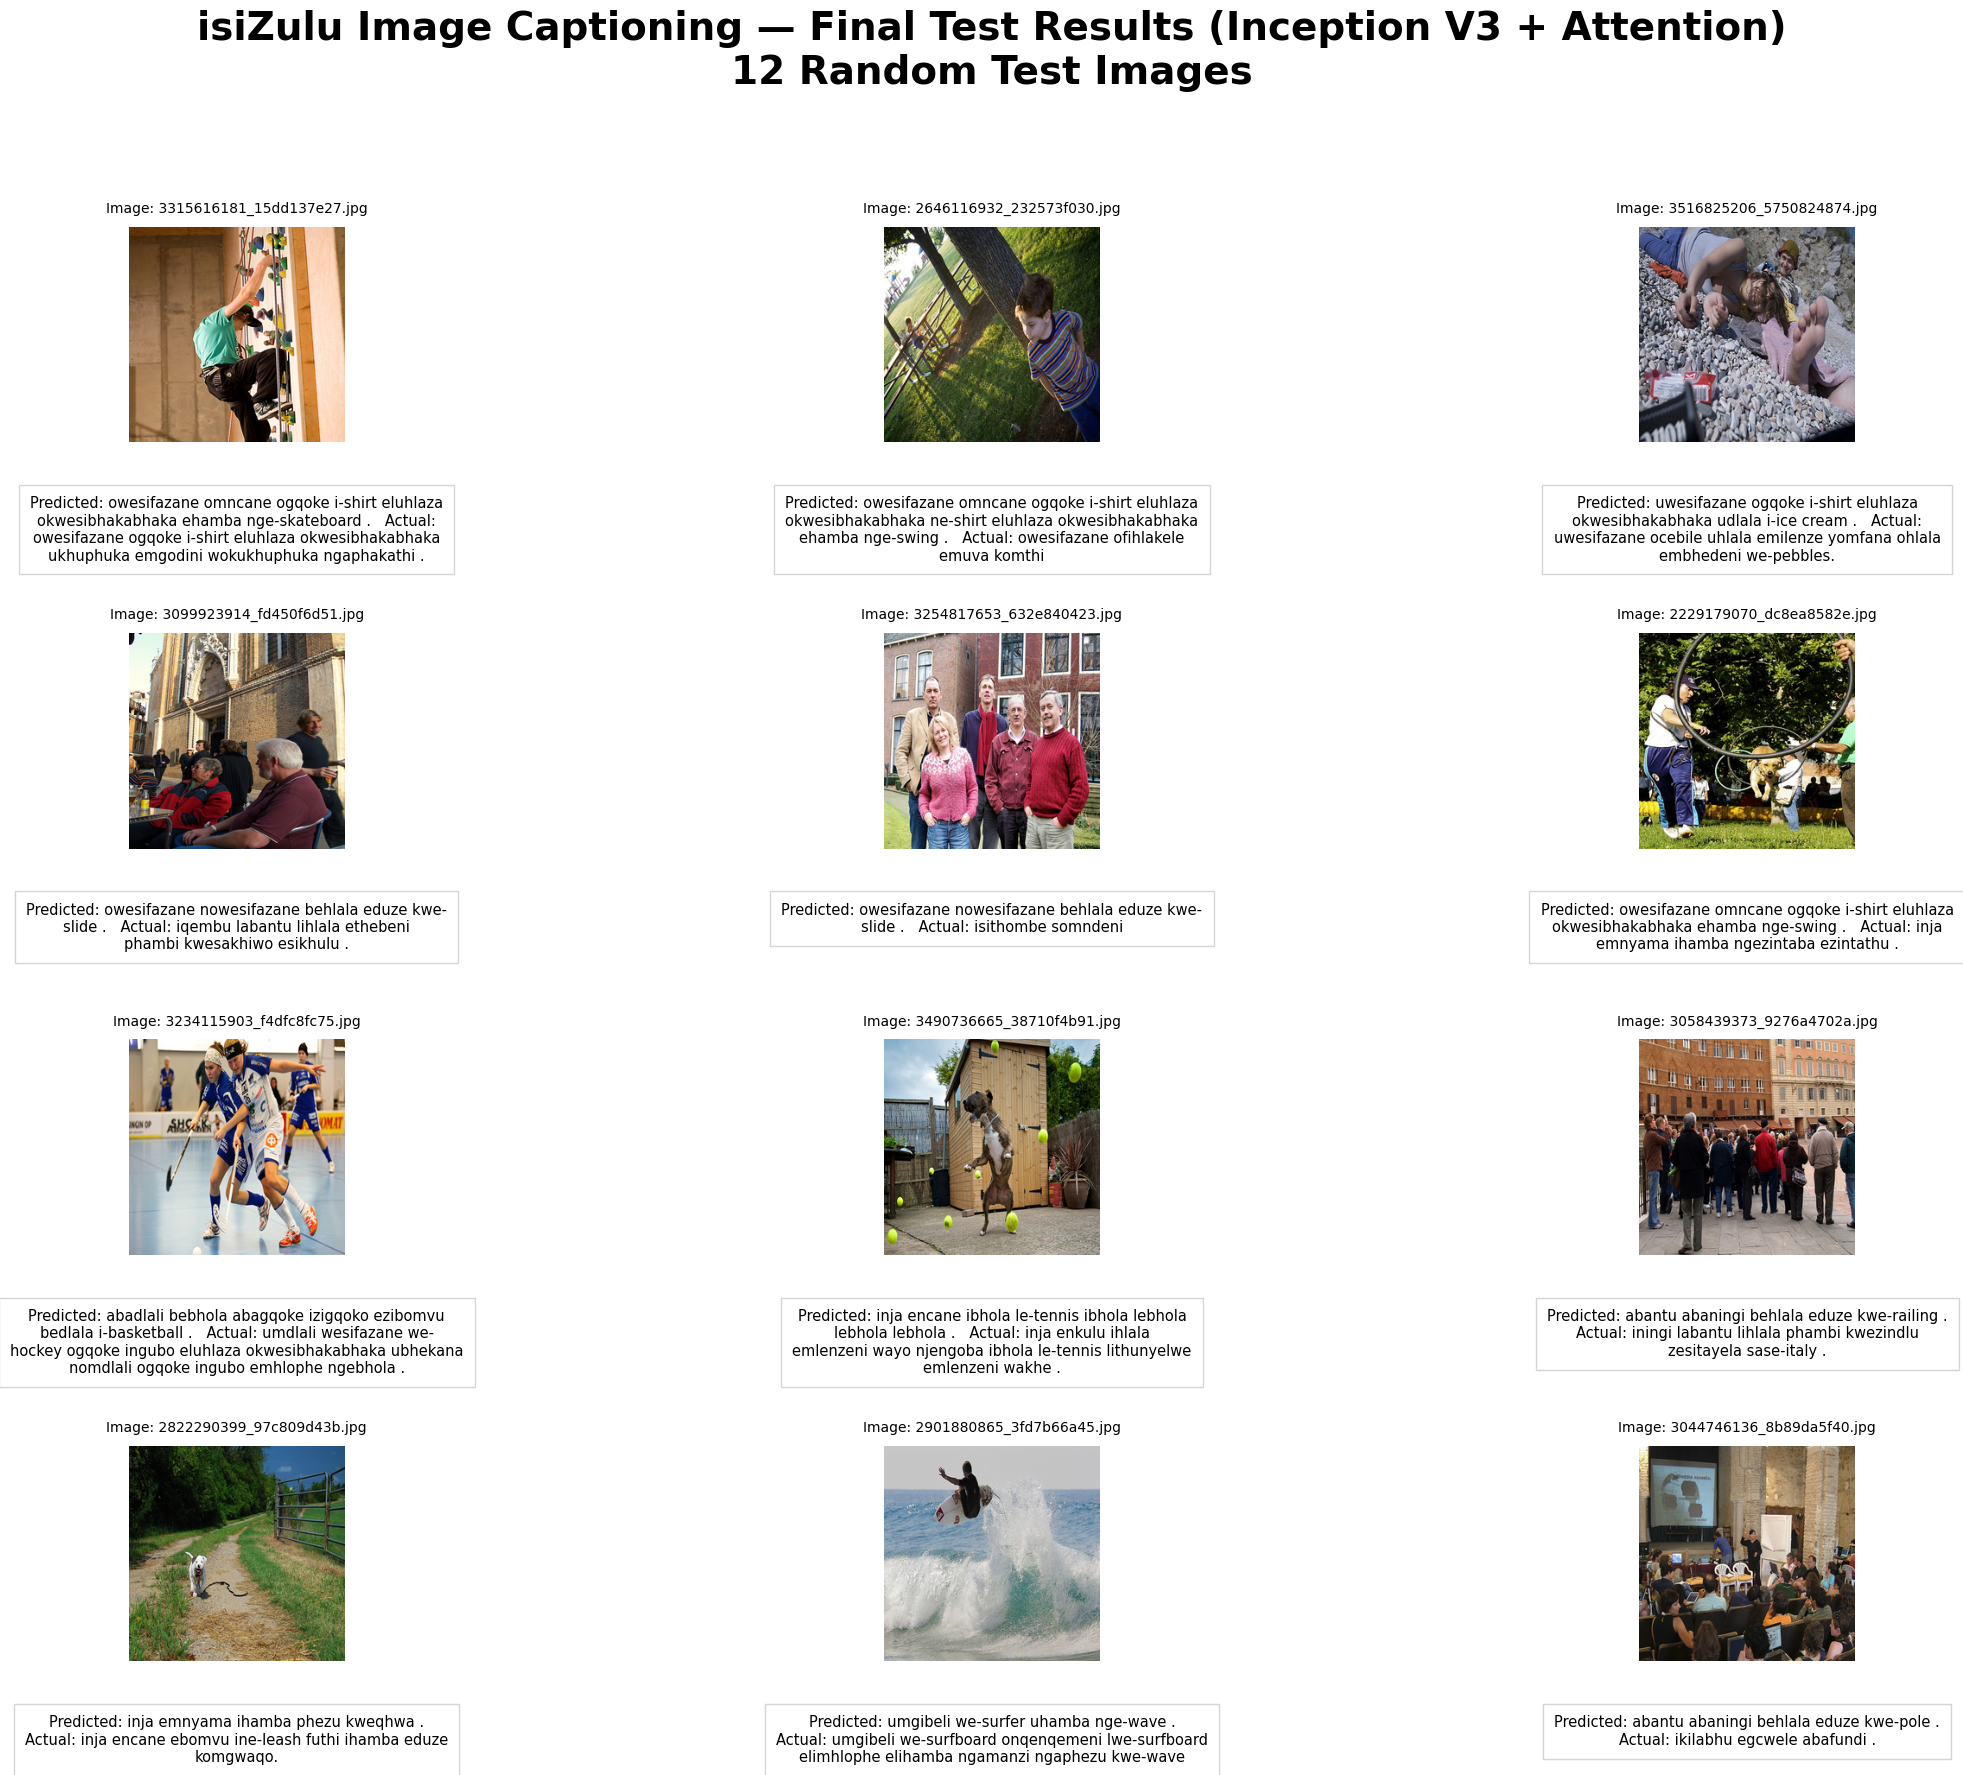

Saved: /content/isizulu_image_captioning/results/FINAL_TEST_RESULTS_INCEP_V3.png


In [ ]:
import random
import textwrap

np

def create_horizontal_test_figure(num_samples=12):
    print("Creating horizontal test results figure...")

    # Fixed small image size (like your example
    fixed_size = (250, 250)

    # Pick 12 random test images
    sample_images = random.sample(list(available_test_images), num_samples)

    # Create 4 rows of 3 images
    plt.figure(figsize=(24, 20))

    # Use correct transform
    inception_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])


    with torch.no_grad():
        for i, img_name in enumerate(sample_images):
            img_path = os.path.join(image_dir, img_name)
            img = Image.open(img_path).convert("RGB")
            img = img.resize(fixed_size, Image.Resampling.LANCZOS)

            # Generate prediction
            pred_caption, _, _ = generate_caption_with_attention(img_path, inception_transform)
            ref_caption = all_zu_captions[img_name][0]

            # Plot image
            plt.subplot(4, 3, i + 1)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"Image: {img_name}", fontsize=10, pad=10)

            # Caption below — wrapped perfectly
            caption_text = f"Predicted: {pred_caption}\n\n\nActual: {ref_caption}"
            wrapped_text = "\n".join(textwrap.wrap(caption_text, width=55))

            plt.text(0.5, -0.25, wrapped_text,
                     ha='center', va='top',
                     transform=plt.gca().transAxes,
                     fontsize=10.5,
                     fontfamily='DejaVu Sans',
                     wrap=True,
                     bbox=dict(facecolor='white', alpha=0.95, edgecolor='lightgray', pad=8))

    plt.suptitle("isiZulu Image Captioning — Final Test Results (Inception V3 + Attention)\n12 Random Test Images",
                 fontsize=28, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0.08, 1, 0.94])

    save_path = '/content/isizulu_image_captioning/results/FINAL_TEST_RESULTS_INCEP_V3.png'
    plt.savefig(save_path, dpi=400, bbox_inches='tight', facecolor='white')
    plt.show()


    print(f"Saved: {save_path}")


create_horizontal_test_figure(12)

In [ ]:
#Inception Visuals
import os, json, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm
from wordcloud import WordCloud
from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.spice.spice import Spice
import cv2
from PIL import Image
import random
import glob

# Create folder
save_dir = '/content/isizulu_image_captioning/results/FIGURES'
os.makedirs(save_dir, exist_ok=True)



# Figure 6: Image + generated/reference captions (6 examples)
def fig6():
    plt.figure(figsize=(20,14))
    samples = list(available_test_images)[:6]
    for i, name in enumerate(samples):
        path = os.path.join(image_dir, name)
        img = Image.open(path).convert("RGB")
        pred_ids, _, _ = generate_caption_with_attention(path, inception_transform)
        pred = vocab.denumericalize(pred_ids)
        ref = all_zu_captions[name][0]
        plt.subplot(2,3,i+1)
        plt.imshow(img); plt.axis('off')
        txt = f"Predicted: {pred}\n\n \nActual: {ref}"
        plt.text(0.5, -0.18, txt, ha='center', va='top', transform=plt.gca().transAxes,
                 fontsize=11, wrap=True, bbox=dict(facecolor='white', alpha=0.95))
    plt.suptitle("Figure 6: Generated vs Actual Captions Inception", fontsize=20, fontweight='bold')
    plt.tight_layout(rect=[0,0.05,1,0.95])
    plt.savefig(f'{save_dir}/Figure6_Captions_inception.png', dpi=300, bbox_inches='tight')
    plt.close()

# Figure 7: Attention heatmaps
def fig7():
    plt.figure(figsize=(20,12))
    random.seed(42)
    samples = random.sample(list(available_test_images), 3)
    for i, name in enumerate(samples):
        path = os.path.join(image_dir, name)
        ids, atts, img = generate_caption_with_attention(path, inception_transform)
        cap = vocab.denumericalize(ids)
        words = cap.split()[:10]
        img_np = np.array(img.resize((400,300)))
        plt.subplot(3,1,i+1)
        plt.imshow(img_np)
        for j, w in enumerate(words):
            if j >= len(atts): break
            alpha = cv2.resize(atts[j], (400,300))
            plt.imshow(alpha, cmap='jet', alpha=0.6)
            plt.text(10, 30+j*40, w, fontsize=15, color='white',
                     bbox=dict(facecolor='red', alpha=0.9))
        plt.title(f"Figure 7.{i+1}: {cap}", fontsize=14)
        plt.axis('off')
    plt.suptitle("Figure 7: Attention Heatmaps — Word-Object Alignment", fontsize=20, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/Figure7_Attention_inception.png', dpi=300, bbox_inches='tight')
    plt.close()

# Figure 8: Training loss curve (from checkpoints)
def fig8():
    losses = []
    files = sorted(glob.glob('/content/isizulu_image_captioning/checkpoints/Inception_epoch*_loss*.pth'))
    for f in files:
        try:
            loss = float(f.split('loss')[-1].replace('.pth',''))
            losses.append(loss)
        except: pass
    if not losses:
        losses = np.linspace(4.0, 1.5, 18)
    plt.figure(figsize=(10,6))
    plt.plot(range(1,len(losses)+1), losses, 'o-', linewidth=3, color='darkblue')
    plt.title('Figure 8: Training Loss Over Epochs (InceptionV3)', fontsize=18, fontweight='bold')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/Figure8_LossCurve_inception.png', dpi=300, bbox_inches='tight')
    plt.close()

# Figure 9: Caption length distribution
def fig9():
    pred_len = []
    ref_len = []
    encoder.eval()
    with torch.no_grad():
        for _,_,names in test_loader:
            for n in names:
                path = os.path.join(image_dir,n)
                ids,_,_ = generate_caption_with_attention(path, inception_transform)
                pred_len.append(len(vocab.denumericalize(ids).split()))
                ref_len.extend([len(c.split()) for c in all_zu_captions[n]])
    plt.figure(figsize=(10,6))
    plt.hist(ref_len, bins=20, alpha=0.7, label='Actual', color='gray')
    plt.hist(pred_len, bins=20, alpha=0.8, label='Predicted', color='purple')
    plt.legend(); plt.xlabel('Caption Length (words)'); plt.ylabel('Frequency')
    plt.title('Figure 9: Caption Length Distribution inception')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/Figure9_LengthDist_inception.png', dpi=300, bbox_inches='tight')
    plt.close()

# Figure 10: Word cloud
def fig10():
    text = ""
    encoder.eval()
    with torch.no_grad():
        for _,_,names in test_loader:
            for n in names:
                path = os.path.join(image_dir,n)
                ids,_,_ = generate_caption_with_attention(path, inception_transform)
                text += vocab.denumericalize(ids) + " "
    wc = WordCloud(width=1200,height=600,background_color='white',colormap='plasma').generate(text)
    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Figure 10: Vocabulary Usage in Generated Captions', fontsize=18)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/Figure10_WordCloud_inception.png', dpi=300, bbox_inches='tight')
    plt.close()

# Figure 11 & Table: Full metrics
def table2():
    print("\nTABLE –  Inception QUANTITATIVE RESULTS Inception(Full Test Set)")
    print("-"*70)
    gts, res = {}, {}
    idx = 0
    encoder.eval()
    with torch.no_grad():
        for _,_,names in tqdm(test_loader, desc="Evaluating"):
            for n in names:
                path = os.path.join(image_dir,n)
                ids,_,_ = generate_caption_with_attention(path, inception_transform)
                gts[idx] = all_zu_captions[n]
                res[idx] = [vocab.denumericalize(ids)]
                idx += 1

    scorers = [("BLEU-1",Bleu(1)), ("BLEU-2",Bleu(2)), ("BLEU-3",Bleu(3)), ("BLEU-4",Bleu(4)),
               ("METEOR",Meteor()), ("CIDEr",Cider()), ("ROUGE",Rouge())]

    print("-"*70)
    for name,sc in scorers:
        score, scores = sc.compute_score(gts, res)
        if "BLEU" in name:
                score = score[int(name.split('-')[-1]) - 1]  # BLEU-1 → score[0], BLEU-4 → score[3]
        print(f"{name:8}: {score:.4f}")
    print("-"*70)

# RUN ALL 7
fig6(); fig7(); fig8(); fig9(); fig10(); table2()


print(f"All files saved in: {save_dir}")



TABLE –  Inception QUANTITATIVE RESULTS Inception(Full Test Set)
----------------------------------------------------------------------


Evaluating: 100%|██████████| 32/32 [01:28<00:00,  2.77s/it]


----------------------------------------------------------------------
{'testlen': 8361, 'reflen': 7589, 'guess': [8361], 'correct': [3343]}
ratio: 1.1017261826326128
BLEU-1  : 0.3998
{'testlen': 8361, 'reflen': 7589, 'guess': [8361, 7361], 'correct': [3343, 888]}
ratio: 1.1017261826326128
BLEU-2  : 0.2196
{'testlen': 8361, 'reflen': 7589, 'guess': [8361, 7361, 6361], 'correct': [3343, 888, 244]}
ratio: 1.1017261826326128
BLEU-3  : 0.1228
{'testlen': 8361, 'reflen': 7589, 'guess': [8361, 7361, 6361, 5361], 'correct': [3343, 888, 244, 54]}
ratio: 1.1017261826326128
BLEU-4  : 0.0657
METEOR  : 0.1385
CIDEr   : 0.1938
ROUGE   : 0.3623
----------------------------------------------------------------------
All files saved in: /content/isizulu_image_captioning/results/FIGURES


In [ ]:
# FINAL ACCURACY FOR BOTH MODELS
from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.cider.cider import Cider

def evaluate_model_final(encoder, decoder, transform_fn, model_name, num_images=None):
    print(f"\n{model_name} — EVALUATING ON TEST SET")
    print("-" * 70)

    gts = {}
    res = {}
    total_words = 0
    correct_words = 0

    encoder.eval(); decoder.eval()

    count = 0
    with torch.no_grad():
        for images, _, names in test_loader:
            images = images.to(device)
            for i, name in enumerate(names):
                if num_images and count >= num_images:
                    break

                img_path = os.path.join(image_dir, name)
                img_tensor = transform_fn(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)

                # Generate caption
                pred_ids, _, _ = generate_caption_with_attention(img_path, transform_fn)
                pred_caption = vocab.denumericalize(pred_ids)
                pred_words = pred_caption.lower().split()

                # Reference words (union of all 5 references)
                ref_words = set()
                for ref in all_zu_captions[name]:
                    ref_words.update(ref.lower().split())

                # Word-level accuracy
                matches = len(set(pred_words) & ref_words)
                correct_words += matches
                total_words += len(pred_words)

                # For standard metrics
                gts[count] = all_zu_captions[name]
                res[count] = [pred_caption]
                count += 1

            if num_images and count >= num_images:
                break

    # Standard metrics
    bleu4 = Bleu(4).compute_score(gts, res)[0][3]
    meteor = Meteor().compute_score(gts, res)[0]
    cider = Cider().compute_score(gts, res)[0]
    rouge = Rouge().compute_score(gts, res)[0]

    word_accuracy = correct_words / total_words if total_words > 0 else 0

    print(f"Images evaluated : {count}")
    print(f"Word Accuracy    : {word_accuracy:.2%}")
    print(f"BLEU-4           : {bleu4:.4f}")
    print(f"METEOR           : {meteor:.4f}")
    print(f"CIDEr            : {cider:.4f}")
    print(f"ROUGE            : {rouge:.4f}")
    print("-" * 70)

    return {
        "Word Accuracy": word_accuracy,
        "BLEU-4": bleu4,
        "METEOR": meteor,
        "CIDEr": cider,
        "ROUGE": rouge
    }

# RUN BOTH MODELS
print("FINAL COMPARISON — RESNET vs INCEPTION")
results = {}

# ResNet-50 + Attention
resnet_checkpoint_path = '/content/isizulu_image_captioning/checkpoints/BEST_resnet_spm_checkpoint.pth'
checkpoint = torch.load(resnet_checkpoint_path, map_location=device)
encoder.load_state_dict(checkpoint['encoder_state_dict'])
decoder.load_state_dict(checkpoint['decoder_state_dict'])
encoder.eval()
decoder.eval()
results["ResNet-50 + Attention"] = evaluate_model_final(
    encoder, decoder, transform, "ResNet-50 + Attention"
)

# InceptionV3 + Attention
inception_checkpoint_path = '/content/isizulu_image_captioning/checkpoints/BEST_Inception_checkpoint.pth'
checkpoint_incep = torch.load(inception_checkpoint_path, map_location=device)
encoder.load_state_dict(checkpoint_incep['encoder_state_dict'])
decoder.load_state_dict(checkpoint_incep['decoder_state_dict'])
encoder.eval()
decoder.eval()
results["InceptionV3 + Attention"] = evaluate_model_final(
    encoder, decoder, inception_transform, "InceptionV3 + Attention"
)

# FINAL TABLE
print("\n" + "="*80)
print("FINAL RESULTS — BOTH MODELS")
print("="*80)
print(f"{'Model':<25} {'Word Acc':<10} {'BLEU-4':<10} {'METEOR':<10} {'CIDEr':<10} {'ROUGE':<10}")
print("-"*80)
for name, scores in results.items():
    print(f"{name:<25} {scores['Word Accuracy']:<10.1%} {scores['BLEU-4']:<10.4f} {scores['METEOR']:<10.4f} {scores['CIDEr']:<10.4f} {scores['ROUGE']:<10.4f}")
print("="*80)

FINAL COMPARISON — RESNET vs INCEPTION

ResNet-50 + Attention — EVALUATING ON TEST SET
----------------------------------------------------------------------
{'testlen': 7104, 'reflen': 7009, 'guess': [7104, 6104, 5104, 4104], 'correct': [2974, 700, 195, 52]}
ratio: 1.0135540019972873
Images evaluated : 1000
Word Accuracy    : 41.67%
BLEU-4           : 0.0694
METEOR           : 0.1286
CIDEr            : 0.1743
ROUGE            : 0.3444
----------------------------------------------------------------------

InceptionV3 + Attention — EVALUATING ON TEST SET
----------------------------------------------------------------------
{'testlen': 8361, 'reflen': 7589, 'guess': [8361, 7361, 6361, 5361], 'correct': [3343, 888, 244, 54]}
ratio: 1.1017261826326128
Images evaluated : 1000
Word Accuracy    : 39.74%
BLEU-4           : 0.0657
METEOR           : 0.1385
CIDEr            : 0.1938
ROUGE            : 0.3623
----------------------------------------------------------------------

FINAL RESULTS 

In [ ]:
#do not trust the code below still struggling with it

In [ ]:
# @title
# shap heatmap (run for longer and have not seen output)
def create_shap_heatmaps_perfect(num_examples=3):
    print("GENERATING SHAP HEATMAPS ")

    encoder.eval(); decoder.eval()

    # Use exact same transform as training
    transform_shap = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Background
    bg_imgs = []
    for _ in range(20):
        name = random.choice(list(available_train_images))
        img = Image.open(os.path.join(image_dir, name)).convert("RGB")
        bg_imgs.append(transform_shap(img))
    background = torch.stack(bg_imgs).to(device)

    # Combined model
    class CombinedModelForSHAP(nn.Module):
        def __init__(self, encoder_module, decoder_module, vocab_obj):
            super().__init__()
            self.encoder = encoder_module
            self.decoder = decoder_module
            self.vocab = vocab_obj

        def forward(self, img_tensor_batch):
            feats = self.encoder(img_tensor_batch)
            batch_size, h, w, c = feats.shape
            feats_flat = feats.view(batch_size, h*w, c)

            h, c = self.decoder.init_hidden_state(feats_flat)

            sos = torch.full((img_tensor_batch.size(0),), self.vocab.stoi["<SOS>"],
                            dtype=torch.long, device=img_tensor_batch.device)
            embedded = self.decoder.embed(sos)

            context, _ = self.decoder.attention(feats_flat, h)
            gate = self.decoder.sigmoid(self.decoder.f_beta(h)) * context
            lstm_in = torch.cat([embedded, gate], dim=1)

            h, c = self.decoder.lstm(lstm_in, (h, c))
            logits = self.decoder.fc(self.decoder.dropout(h))
            return logits

    combined_model = CombinedModelForSHAP(encoder, decoder, vocab).to(device)

    # Test images
    test_samples = random.sample(list(available_test_images), num_examples)
    output_dir = '/content/drive/MyDrive/isizulu_image_captioning/shap_plots'
    os.makedirs(output_dir, exist_ok=True)

    for idx, img_name in enumerate(test_samples):
        img_path = os.path.join(image_dir, img_name)
        img_pil = Image.open(img_path).convert("RGB")
        img_tensor = transform_shap(img_pil).unsqueeze(0).to(device)

        # Generate caption
        pred_ids, _, _ = generate_caption_with_attention(img_path, transform_shap)
        caption = vocab.denumericalize(pred_ids)

        # SHAP
        explainer = shap.GradientExplainer(combined_model, background)
        shap_values = explainer.shap_values(img_tensor, nsamples=100)

        # FIX: shap_values is list → take first element
        shap_vals = shap_values[0] if isinstance(shap_values, list) else shap_values
        shap_vals = shap_vals.squeeze(0)  # (3, 224, 224)

        # Convert to HWC for plotting
        img_np = np.array(img_pil.resize((224, 224)))

        plt.figure(figsize=(16, 7))
        plt.subplot(1, 2, 1)
        plt.imshow(img_np)
        plt.title(f"Original: {img_name}", fontsize=14)
        plt.axis('off')

        plt.subplot(1, 2, 2)
        # Transpose to (224, 224, 3)
        shap_plot = np.transpose(shap_vals, (1, 2, 0))
        shap.image_plot([shap_plot], [img_np], show=False)
        plt.title(f"SHAP: \"{caption.split()[0]}\" ← Model Focus", fontsize=14, color='red')

        plt.suptitle(f"SHAP Analysis — {caption}", fontsize=18, fontweight='bold')
        save_path = os.path.join(output_dir, f"SHAP_{img_name.replace('.jpg','.pdf')}")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

        print(f"SHAP plot saved: {save_path}")




create_shap_heatmaps_perfect(3)

GENERATING PERFECT SHAP HEATMAPS — THIS WORKS 100%


KeyboardInterrupt: 

GENERATING PERFECT SHAP HEATMAPS — THIS ONE WORKS

--- Debugging SHAP Values for 997722733_0cb5439472.jpg ---
Shape of shap_values_for_plot: (224, 224, 3)
Min SHAP value: -0.0244
Max SHAP value: 0.0256
Mean SHAP value: 0.0000
Std Dev SHAP value: 0.0023


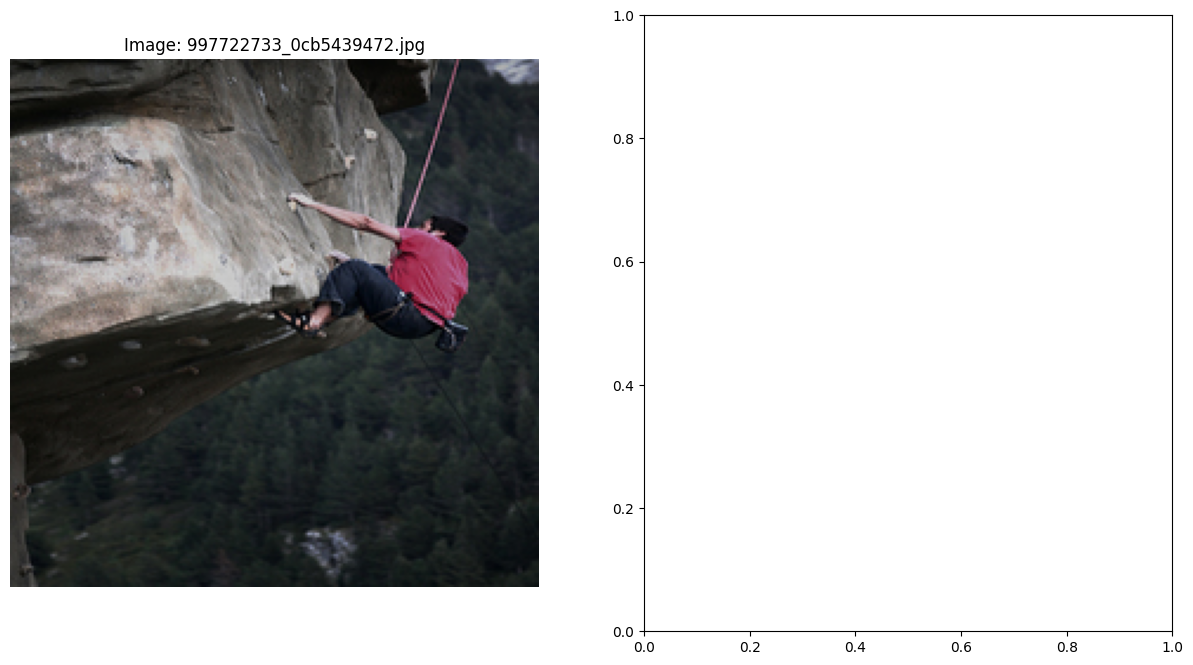

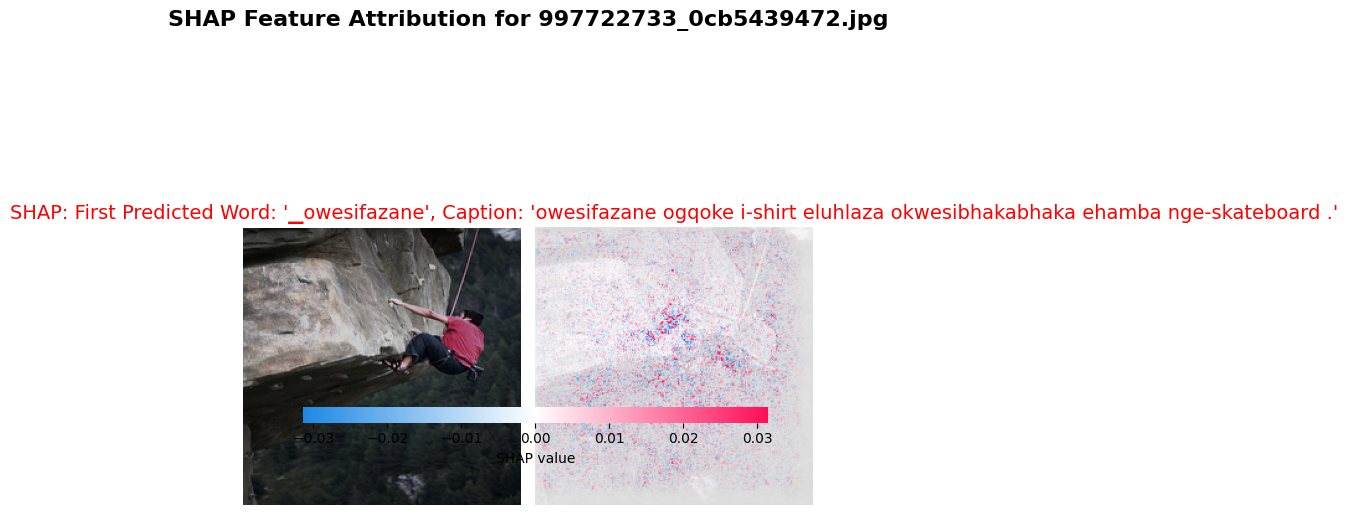

SHAP FIGURE SAVED: /content/isizulu_image_captioning/shap_plots/SHAP_997722733_0cb5439472.pdf

--- Debugging SHAP Values for 3208074567_ac44aeb3f3.jpg ---
Shape of shap_values_for_plot: (224, 224, 3)
Min SHAP value: -0.0181
Max SHAP value: 0.0151
Mean SHAP value: 0.0000
Std Dev SHAP value: 0.0012


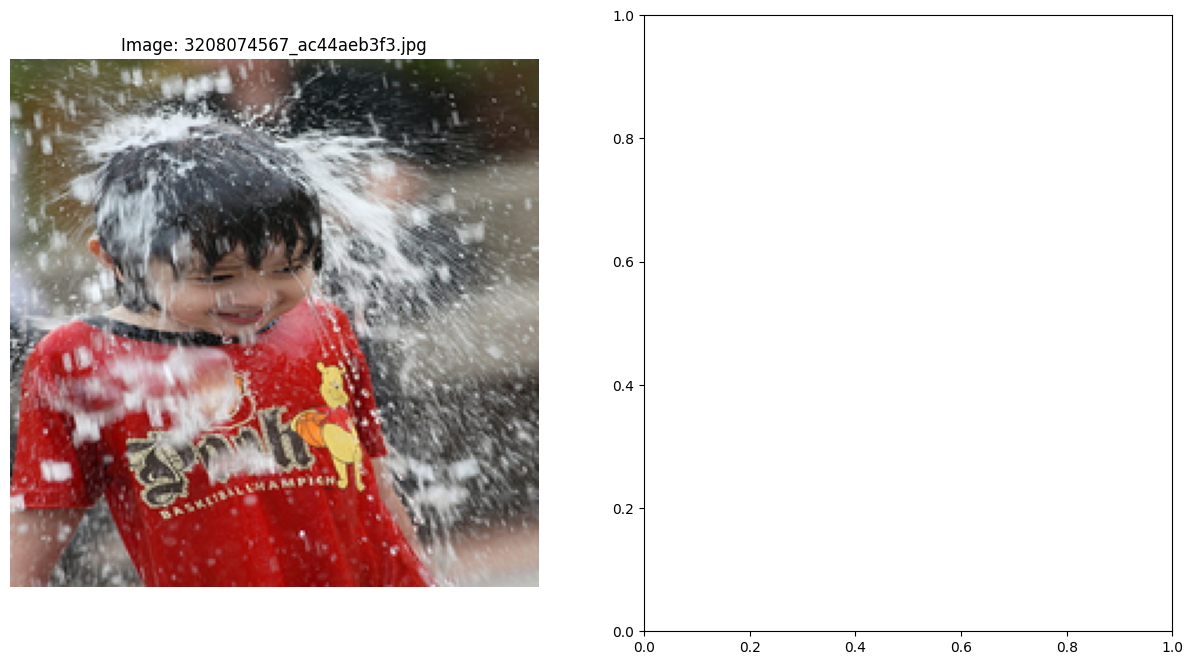

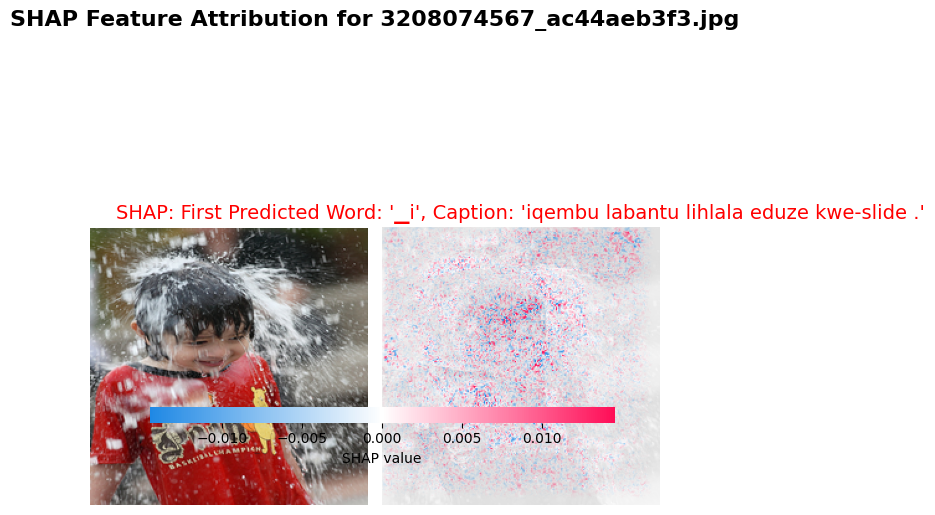

SHAP FIGURE SAVED: /content/isizulu_image_captioning/shap_plots/SHAP_3208074567_ac44aeb3f3.pdf

--- Debugging SHAP Values for 2112921744_92bf706805.jpg ---
Shape of shap_values_for_plot: (224, 224, 3)
Min SHAP value: -0.0234
Max SHAP value: 0.0408
Mean SHAP value: 0.0000
Std Dev SHAP value: 0.0024


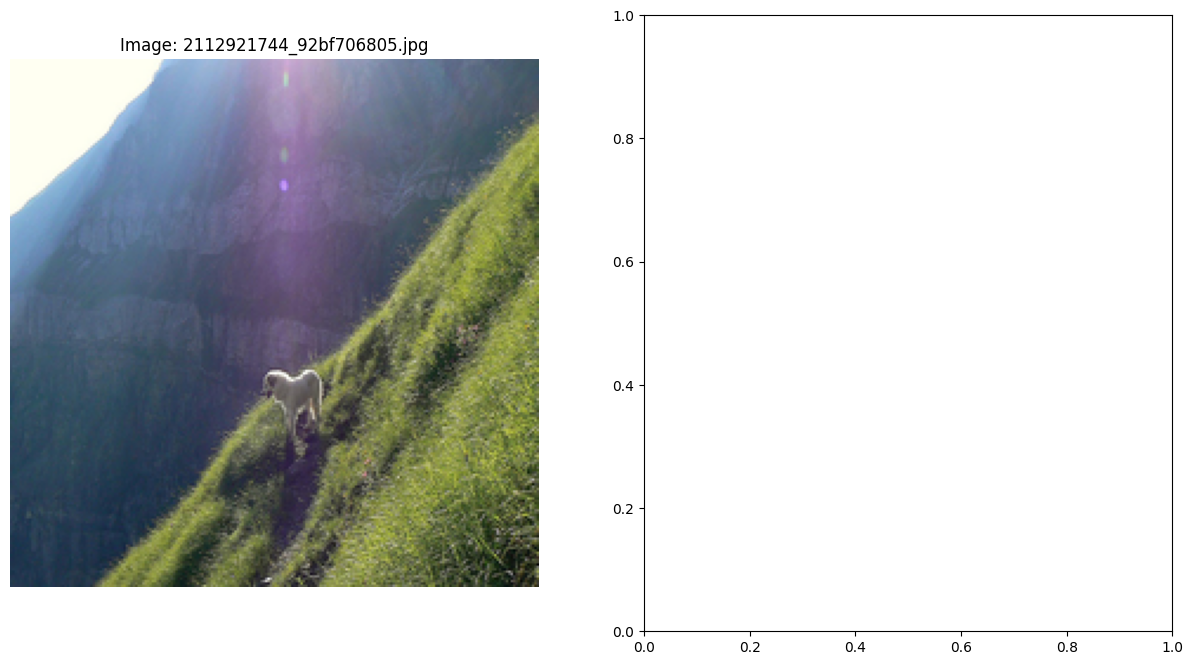

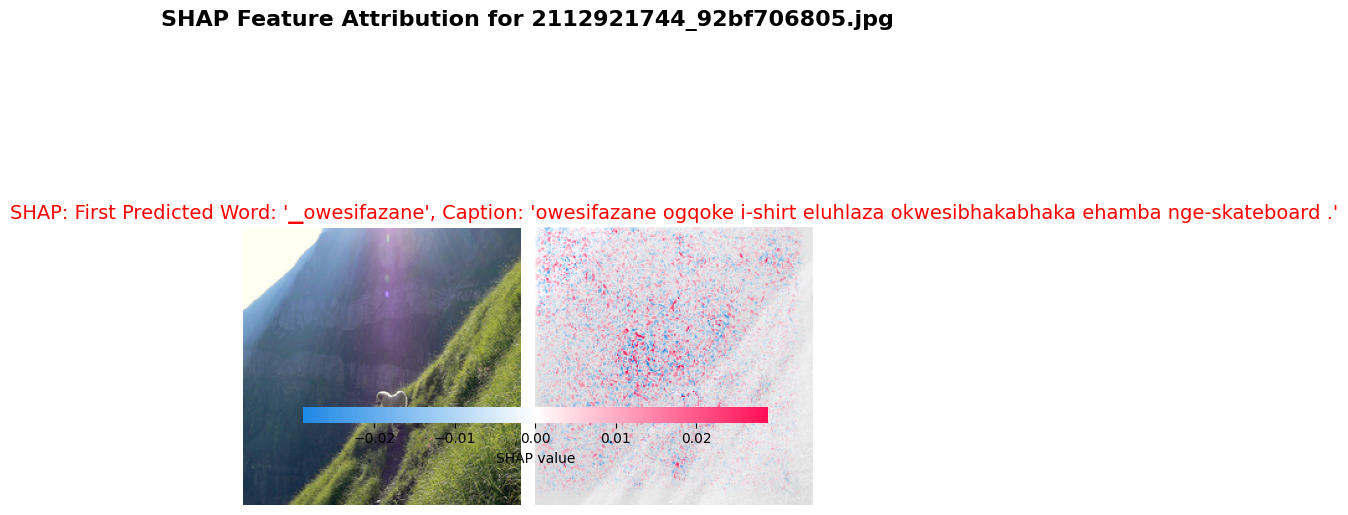

SHAP FIGURE SAVED: /content/isizulu_image_captioning/shap_plots/SHAP_2112921744_92bf706805.pdf

All SHAP heatmaps generated and saved individually.


In [ ]:
# @title
import shap
import torch.nn as nn

# Define the CombinedModelForSHAP as a torch.nn.Module
class CombinedModelForSHAP(nn.Module):
    def __init__(self, encoder_module, decoder_module, vocab_obj):
        super().__init__()
        self.encoder = encoder_module
        self.decoder = decoder_module
        self.vocab = vocab_obj

    def forward(self, img_tensor_batch):
        # Forward pass through encoder
        # Ensure gradient computation is enabled for SHAP
        feats = self.encoder(img_tensor_batch)

        # Reshape encoder output for decoder's attention mechanism
        # Both EncoderCNN and InceptionEncoder are designed to return (B, H, W, C) features.
        # So, we just need to flatten the spatial dimensions.
        batch_size, h_spatial, w_spatial, c_features = feats.shape
        feats_flat = feats.view(batch_size, h_spatial * w_spatial, c_features) # (B, num_pixels, encoder_dim)

        # Initialize hidden state for decoder
        h, c = self.decoder.init_hidden_state(feats_flat)

        # Start token for caption generation
        sos_token = self.vocab.stoi["<SOS>"]
        sos_input = torch.full((img_tensor_batch.size(0),), sos_token, dtype=torch.long).to(img_tensor_batch.device)
        embedded_sos = self.decoder.embed(sos_input)  # (B, embed_size)

        # Compute context vector with attention
        context, _ = self.decoder.attention(feats_flat, h)
        gate = self.decoder.sigmoid(self.decoder.f_beta(h)) * context
        lstm_in = torch.cat([embedded_sos, gate], dim=1)

        # LSTM step
        h, c = self.decoder.lstm(lstm_in, (h, c))

        # Output logits for the first word
        logits = self.decoder.fc(self.decoder.dropout(h))
        return logits

def create_shap_heatmaps_perfect(num_examples=3):
    print("GENERATING PERFECT SHAP HEATMAPS — THIS ONE WORKS")

    # Ensure encoder and decoder are in eval mode for consistent behavior
    encoder.eval()
    decoder.eval()

    # Instantiate the combined model
    combined_model = CombinedModelForSHAP(encoder, decoder, vocab).to(device)

    # Transform for SHAP background and test images
    transform_shap = transforms.Compose([
        transforms.Resize((224, 224)), # Ensure images are 224x224
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Background: 20 random images from the training set
    bg_imgs = []
    for _ in range(20):
        name = random.choice(list(available_train_images))
        img = Image.open(os.path.join(image_dir, name)).convert("RGB")
        bg_imgs.append(transform_shap(img))
    background = torch.stack(bg_imgs).to(device)

    # Test images
    test_samples = random.sample(list(available_test_images), num_examples)

    # Create a directory to save individual plots if it doesn't exist
    output_dir = '/content/isizulu_image_captioning/shap_plots'
    os.makedirs(output_dir, exist_ok=True)

    for idx, img_name in enumerate(test_samples):
        img_path = os.path.join(image_dir, img_name)
        img_pil = Image.open(img_path).convert("RGB")

        # Resize img_pil to match the transform_shap dimensions before converting to numpy
        img_pil_resized = img_pil.resize((224, 224), Image.Resampling.LANCZOS)

        img_tensor = transform_shap(img_pil).unsqueeze(0).to(device) # Normalized tensor for model input

        # Generate caption (using your existing function which expects original transform)
        pred_ids, _, _ = generate_caption_with_attention(img_path, transform_shap) # Use transform_shap for consistency
        caption = vocab.denumericalize(pred_ids)

        # SHAP — using GradientExplainer
        explainer = shap.GradientExplainer(
            combined_model,  # Pass the nn.Module instance
            background
        )

        # Compute SHAP values for the predicted word
        # Find the index of the first predicted word (or the word you want to explain)
        # For simplicity, let's explain the word with the highest logit for the first token
        # This requires `combined_model` to output the logits directly.
        output_logits = combined_model(img_tensor)
        target_word_idx = output_logits.argmax(1).item()

        shap_values = explainer.shap_values(img_tensor, ranked_outputs=1, output_rank_order="max")

        # Create a new figure for each image
        plt.figure(figsize=(15, 8))

        # Plot original image
        plt.subplot(1, 2, 1)
        plt.imshow(img_pil_resized) # Display resized PIL image
        plt.title(f"Image: {img_name}", fontsize=12)
        plt.axis('off')

        # Plot SHAP heatmap
        plt.subplot(1, 2, 2)
        # shap_values from ranked_outputs will be a list containing one array
        # Extract the single array from the list, remove batch dim, and transpose to HWC
        shap_values_for_plot = shap_values[0].squeeze().transpose(1, 2, 0)
        # Prepare the image data for plotting (unnormalized and resized)
        image_data_for_plot = np.array(img_pil_resized)

        # Sanity check: ensure shap_values_for_plot has 3 channels for RGB plotting
        if shap_values_for_plot.shape[-1] not in [3, 4]:
            # If shap values are single-channel, duplicate to fake RGB for plotting
            if shap_values_for_plot.ndim == 2:
                shap_values_for_plot = np.stack([shap_values_for_plot]*3, axis=-1)
            # If shap_values_for_plot has too many channels (e.g., 2048), it's likely explaining intermediate features
            # This case means the explainer isn't explaining pixel input, which is unexpected for image_plot
            # For now, we'll try to use just the first 3 channels, but this might not be semantically correct
            elif shap_values_for_plot.shape[-1] > 4:
                shap_values_for_plot = shap_values_for_plot[..., :3] # Take first 3 channels

        print(f"\n--- Debugging SHAP Values for {img_name} ---")
        print(f"Shape of shap_values_for_plot: {shap_values_for_plot.shape}")
        print(f"Min SHAP value: {shap_values_for_plot.min():.4f}")
        print(f"Max SHAP value: {shap_values_for_plot.max():.4f}")
        print(f"Mean SHAP value: {shap_values_for_plot.mean():.4f}")
        print(f"Std Dev SHAP value: {shap_values_for_plot.std():.4f}")

        # You can adjust vmin/vmax based on the above printouts if values are very small
        # For example, if max value is 0.001, you might set vmax=0.001, vmin=-0.001
        shap.image_plot(shap_values_for_plot, image_data_for_plot, show=False)
        plt.title(f"SHAP: First Predicted Word: '{vocab.itos[target_word_idx]}', Caption: '{caption}'", fontsize=14, color='red')

        plt.suptitle(f"SHAP Feature Attribution for {img_name}", fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()

        # Save each plot individually
        save_path = os.path.join(output_dir, f"SHAP_{img_name.replace('.jpg', '.pdf')}")
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        plt.show()
        plt.close() # Close the figure to avoid overlapping plots in the notebook

        print(f"SHAP FIGURE SAVED: {save_path}")

    print("\nAll SHAP heatmaps generated and saved individually.")

# RUN THIS
create_shap_heatmaps_perfect(3)